# Fintech Liquidity Forecasting and Reserve Optimization

## Notebook 01 — Business Problem and Synthetic Data Generation

### Objective

The objective of this notebook is to define the business problem, document the main assumptions, construct the project calendar, and generate a realistic and reproducible synthetic dataset representing daily cash outflows from a Fintech.

The forecasting system will estimate future withdrawals and outgoing transfers over a 28-day horizon. These forecasts will later be converted into probabilistic liquidity requirements that balance two competing risks:

- **Liquidity shortfall:** insufficient reserves to cover future cash outflows.
- **Idle capital:** excessive reserves that could otherwise generate returns.

The primary target variable is:

$$
\text{total\_cash\_outflow}
=
\text{withdrawal\_amount}
+
\text{outgoing\_transfer\_amount}
$$

### Initial Assumptions

- The dataset represents one aggregated Fintech operation.
- Observations have a daily frequency.
- All monetary values are synthetic and expressed in **ARS millions**.
- The historical period extends from January 1, 2023, to July 31, 2026.
- The forecasting horizon is 28 days.
- The initial funding lead time is 5 days and remains configurable.
- The generated series will include trend, weekly seasonality, payday effects, month-end effects, holidays, promotions, macroeconomic variation, heteroscedasticity, and documented exceptional events.
- A fixed random seed will guarantee reproducibility.

### Expected Output

This notebook will produce:

1. A validated daily calendar.
2. A documented synthetic data-generating process.
3. A reproducible daily cash-outflow dataset.
4. Initial quality-control tables and visualizations.
5. A processed dataset ready for time-series exploratory analysis.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import holidays

# Reproducibility
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

for directory in [DATA_RAW_DIR, DATA_PROCESSED_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Central project configuration
PROJECT_CONFIG = {
    "start_date": "2023-01-01",
    "end_date": "2026-07-31",
    "frequency": "D",
    "monetary_unit": "ARS million",
    "forecast_horizon_days": 28,
    "funding_lead_time_days": 5,
    "random_seed": RANDOM_SEED,
    "target": "total_cash_outflow",
}

config_table = (
    pd.Series(PROJECT_CONFIG, name="value")
    .rename_axis("parameter")
    .reset_index()
)

config_table

,parameter,value
0,start_date,2023-01-01
1,end_date,2026-07-31
2,frequency,D
3,monetary_unit,ARS million
4,forecast_horizon_days,28
5,funding_lead_time_days,5
6,random_seed,42
7,target,total_cash_outflow


In [4]:
calendar = pd.DataFrame(
    {
        "date": pd.date_range(
            start=PROJECT_CONFIG["start_date"],
            end=PROJECT_CONFIG["end_date"],
            freq=PROJECT_CONFIG["frequency"],
        )
    }
)

# Basic calendar variables known in advance at the forecast origin
calendar["year"] = calendar["date"].dt.year
calendar["quarter"] = calendar["date"].dt.quarter
calendar["month"] = calendar["date"].dt.month
calendar["day_of_month"] = calendar["date"].dt.day
calendar["day_of_week"] = calendar["date"].dt.dayofweek
calendar["day_name"] = calendar["date"].dt.day_name()

calendar["is_weekend"] = calendar["day_of_week"].isin([5, 6]).astype("int8")
calendar["is_month_start"] = calendar["date"].dt.is_month_start.astype("int8")
calendar["is_month_end"] = calendar["date"].dt.is_month_end.astype("int8")

# Initial simplified payday definition.
# It will be reviewed before generating the target series.
# Nominal payday dates: 1st and 15th day of each month
calendar["is_nominal_payday"] = (
    calendar["day_of_month"]
    .isin([1, 15])
    .astype("int8")
)

nominal_paydays = calendar.loc[
    calendar["is_nominal_payday"].eq(1),
    "date",
].copy()

# Move Saturday paydays to Monday (+2 days)
# and Sunday paydays to Monday (+1 day)
weekend_shift = (
    nominal_paydays.dt.dayofweek
    .map({
        5: 2,  # Saturday
        6: 1,  # Sunday
    })
    .fillna(0)
    .astype(int)
)

adjusted_paydays = (
    nominal_paydays
    + pd.to_timedelta(weekend_shift, unit="D")
)

calendar["is_payday"] = (
    calendar["date"]
    .isin(adjusted_paydays)
    .astype("int8")
)

# The payday effect is assumed to persist for three calendar days:
# the adjusted payday and the following two days.
payday_window_dates = pd.DatetimeIndex(
    [
        payday + pd.Timedelta(days=offset)
        for payday in adjusted_paydays
        for offset in range(3)
    ]
)

calendar["is_payday_window"] = (
    calendar["date"]
    .isin(payday_window_dates)
    .astype("int8")
)

calendar[
    [
        "date",
        "day_name",
        "is_weekend",
        "is_nominal_payday",
        "is_payday",
        "is_payday_window",
    ]
].head(20)

#calendar.head(10)

,date,day_name,is_weekend,is_nominal_payday,is_payday,is_payday_window
0,2023-01-01,Sunday,1,1,0,0
1,2023-01-02,Monday,0,0,1,1
2,2023-01-03,Tuesday,0,0,0,1
3,2023-01-04,Wednesday,0,0,0,1
4,2023-01-05,Thursday,0,0,0,0
5,2023-01-06,Friday,0,0,0,0
6,2023-01-07,Saturday,1,0,0,0
7,2023-01-08,Sunday,1,0,0,0
8,2023-01-09,Monday,0,0,0,0
9,2023-01-10,Tuesday,0,0,0,0


In [5]:
expected_dates = pd.date_range(
    PROJECT_CONFIG["start_date"],
    PROJECT_CONFIG["end_date"],
    freq=PROJECT_CONFIG["frequency"],
)

calendar_checks = pd.Series(
    {
        "number_of_rows": len(calendar),
        "expected_number_of_rows": len(expected_dates),
        "start_date": calendar["date"].min(),
        "end_date": calendar["date"].max(),
        "duplicated_dates": calendar["date"].duplicated().sum(),
        "missing_dates": len(expected_dates.difference(calendar["date"])),
        "missing_values": int(calendar.isna().sum().sum()),
        "weekend_days": int(calendar["is_weekend"].sum()),
        "nominal_payday_flags": int(calendar["is_nominal_payday"].sum()),
        "adjusted_payday_flags": int(calendar["is_payday"].sum()),
        "payday_window_days": int(calendar["is_payday_window"].sum()),
    },
    name="value",
).rename_axis("check").reset_index()

calendar_checks

,check,value
0,number_of_rows,1308
1,expected_number_of_rows,1308
2,start_date,2023-01-01 00:00:00
3,end_date,2026-07-31 00:00:00
4,duplicated_dates,0
5,missing_dates,0
6,missing_values,0
7,weekend_days,373
8,nominal_payday_flags,86
9,adjusted_payday_flags,86


In [6]:
# Years covered by the synthetic dataset
calendar_years = sorted(calendar["year"].unique())

# National public holidays in Argentina
argentina_holidays = holidays.country_holidays(
    country="AR",
    years=calendar_years,
    observed=True,
    language="en_US",
)

# Store the holiday name for traceability
calendar["holiday_name"] = (
    calendar["date"]
    .dt.date
    .map(argentina_holidays)
)

calendar["is_holiday"] = (
    calendar["holiday_name"]
    .notna()
    .astype("int8")
)

holiday_dates = set(argentina_holidays.keys())


def move_to_next_business_day(date):
    """
    Move a nominal payday forward until reaching a weekday
    that is not an Argentine national holiday.
    """
    adjusted_date = pd.Timestamp(date)

    while (
        adjusted_date.dayofweek >= 5
        or adjusted_date.date() in holiday_dates
    ):
        adjusted_date += pd.Timedelta(days=1)

    return adjusted_date


# Recalculate operational paydays using weekends and holidays
nominal_paydays = calendar.loc[
    calendar["is_nominal_payday"].eq(1),
    "date",
]

adjusted_paydays = pd.DatetimeIndex(
    nominal_paydays.map(move_to_next_business_day)
)

calendar["is_payday"] = (
    calendar["date"]
    .isin(adjusted_paydays)
    .astype("int8")
)

# Payday effect: operational payday plus the following two calendar days
payday_window_dates = pd.DatetimeIndex(
    [
        payday + pd.Timedelta(days=offset)
        for payday in adjusted_paydays
        for offset in range(3)
    ]
)

calendar["is_payday_window"] = (
    calendar["date"]
    .isin(payday_window_dates)
    .astype("int8")
)

calendar[
    [
        "date",
        "day_name",
        "is_weekend",
        "holiday_name",
        "is_holiday",
        "is_nominal_payday",
        "is_payday",
        "is_payday_window",
    ]
].head(20)

,date,day_name,is_weekend,holiday_name,is_holiday,is_nominal_payday,is_payday,is_payday_window
0,2023-01-01,Sunday,1,New Year's Day,1,1,0,0
1,2023-01-02,Monday,0,NaN,0,0,1,1
2,2023-01-03,Tuesday,0,NaN,0,0,0,1
3,2023-01-04,Wednesday,0,NaN,0,0,0,1
4,2023-01-05,Thursday,0,NaN,0,0,0,0
5,2023-01-06,Friday,0,NaN,0,0,0,0
6,2023-01-07,Saturday,1,NaN,0,0,0,0
7,2023-01-08,Sunday,1,NaN,0,0,0,0
8,2023-01-09,Monday,0,NaN,0,0,0,0
9,2023-01-10,Tuesday,0,NaN,0,0,0,0


In [7]:
adjusted_payday_dates = calendar.loc[
    calendar["is_payday"].eq(1),
    "date",
]

invalid_adjusted_paydays = calendar.loc[
    calendar["is_payday"].eq(1)
    & (
        calendar["is_weekend"].eq(1)
        | calendar["is_holiday"].eq(1)
    )
]

holiday_payday_checks = pd.Series(
    {
        "holiday_days": int(calendar["is_holiday"].sum()),
        "holidays_on_weekends": int(
            (
                calendar["is_holiday"].eq(1)
                & calendar["is_weekend"].eq(1)
            ).sum()
        ),
        "nominal_payday_flags": int(
            calendar["is_nominal_payday"].sum()
        ),
        "adjusted_payday_flags": int(
            calendar["is_payday"].sum()
        ),
        "adjusted_paydays_on_non_business_days": len(
            invalid_adjusted_paydays
        ),
        "payday_window_days": int(
            calendar["is_payday_window"].sum()
        ),
    },
    name="value",
).rename_axis("check").reset_index()

holiday_payday_checks

,check,value
0,holiday_days,73
1,holidays_on_weekends,13
2,nominal_payday_flags,86
3,adjusted_payday_flags,86
4,adjusted_paydays_on_non_business_days,0
5,payday_window_days,258


In [8]:
# Final calendar validation assertions

assert len(calendar) == len(expected_dates), (
    "The calendar does not contain the expected number of dates."
)

assert calendar["date"].duplicated().sum() == 0, (
    "Duplicated dates were detected."
)

assert len(expected_dates.difference(calendar["date"])) == 0, (
    "Missing dates were detected."
)

assert calendar.isna().drop(columns=["holiday_name"]).sum().sum() == 0, (
    "Unexpected missing values were detected."
)

assert calendar["is_nominal_payday"].sum() == 86, (
    "The number of nominal paydays is incorrect."
)

assert calendar["is_payday"].sum() == 86, (
    "Some operational paydays were lost or duplicated."
)

assert invalid_adjusted_paydays.empty, (
    "At least one adjusted payday falls on a weekend or holiday."
)

assert calendar["is_payday_window"].sum() == 258, (
    "The payday-window count differs from the expected value."
)

print("Calendar validation passed successfully.")

Calendar validation passed successfully.


In [9]:
# Create the main daily dataset from the validated calendar
daily_data = calendar.copy()

USER_GENERATION_CONFIG = {
    "initial_active_users": 40_000,
    "annual_growth_rate": 0.20,
    "daily_noise_std": 0.025,
}

# Dedicated random generator for reproducibility of this component
users_rng = np.random.default_rng(
    PROJECT_CONFIG["random_seed"] + 1
)

# Continuous time measured in years
time_index = np.arange(len(daily_data))
years_elapsed = time_index / 365.25

# Structural exponential growth
structural_active_users = (
    USER_GENERATION_CONFIG["initial_active_users"]
    * (1 + USER_GENERATION_CONFIG["annual_growth_rate"])
    ** years_elapsed
)

# Daily activity pattern
weekday_active_user_factor = {
    0: 1.03,  # Monday
    1: 1.00,  # Tuesday
    2: 0.99,  # Wednesday
    3: 1.00,  # Thursday
    4: 1.06,  # Friday
    5: 0.92,  # Saturday
    6: 0.86,  # Sunday
}

weekly_factor = (
    daily_data["day_of_week"]
    .map(weekday_active_user_factor)
    .to_numpy()
)

# Multiplicative daily variability
daily_noise = users_rng.normal(
    loc=0.0,
    scale=USER_GENERATION_CONFIG["daily_noise_std"],
    size=len(daily_data),
)

active_users = (
    structural_active_users
    * weekly_factor
    * (1 + daily_noise)
)

daily_data["active_users"] = (
    np.maximum(active_users, 1)
    .round()
    .astype(int)
)

daily_data[
    ["date", "day_name", "is_weekend", "active_users"]
].head(10)

,date,day_name,is_weekend,active_users
0,2023-01-01,Sunday,1,34610
1,2023-01-02,Monday,0,41919
2,2023-01-03,Tuesday,0,39454
3,2023-01-04,Wednesday,0,38758
4,2023-01-05,Thursday,0,38084
5,2023-01-06,Friday,0,43538
6,2023-01-07,Saturday,1,36926
7,2023-01-08,Sunday,1,34698
8,2023-01-09,Monday,0,40555
9,2023-01-10,Tuesday,0,41412


In [10]:
active_users_checks = pd.Series(
    {
        "missing_values": int(
            daily_data["active_users"].isna().sum()
        ),
        "non_positive_values": int(
            daily_data["active_users"].le(0).sum()
        ),
        "minimum": int(
            daily_data["active_users"].min()
        ),
        "maximum": int(
            daily_data["active_users"].max()
        ),
        "first_30_days_mean": round(
            daily_data["active_users"].head(30).mean(),
            1,
        ),
        "last_30_days_mean": round(
            daily_data["active_users"].tail(30).mean(),
            1,
        ),
        "overall_mean": round(
            daily_data["active_users"].mean(),
            1,
        ),
    },
    name="value",
).rename_axis("check").reset_index()

active_users_checks

,check,value
0,missing_values,0.0
1,non_positive_values,0.0
2,minimum,33537.0
3,maximum,84553.0
4,first_30_days_mean,39198.8
5,last_30_days_mean,74946.0
6,overall_mean,55284.2


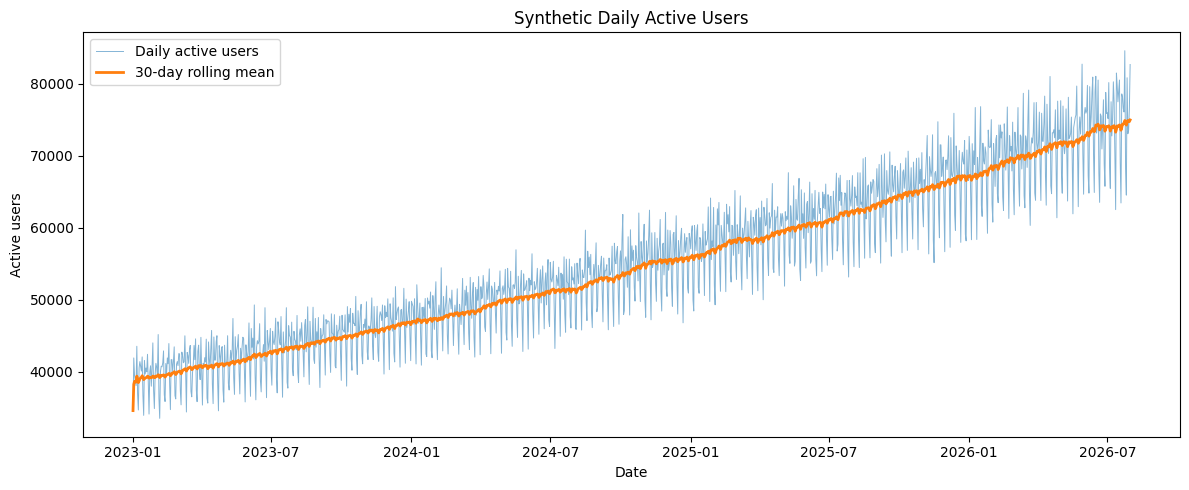

In [11]:
import matplotlib.pyplot as plt

daily_data["active_users_30d_mean"] = (
    daily_data["active_users"]
    .rolling(window=30, min_periods=1)
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    daily_data["date"],
    daily_data["active_users"],
    linewidth=0.7,
    alpha=0.55,
    label="Daily active users",
)

plt.plot(
    daily_data["date"],
    daily_data["active_users_30d_mean"],
    linewidth=2,
    label="30-day rolling mean",
)

plt.title("Synthetic Daily Active Users")
plt.xlabel("Date")
plt.ylabel("Active users")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
daily_data["active_users_relative_to_trend"] = (
    daily_data["active_users"]
    / structural_active_users
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_active_users_profile = (
    daily_data
    .groupby("day_name")["active_users_relative_to_trend"]
    .agg(["mean", "std", "count"])
    .reindex(weekday_order)
    .round(3)
)

weekday_active_users_profile

,mean,std,count
day_name,,,
Monday,1.028,0.026,187
Tuesday,0.998,0.023,187
Wednesday,0.991,0.026,187
Thursday,1.002,0.025,187
Friday,1.060,0.027,187
Saturday,0.919,0.024,186
Sunday,0.861,0.020,187


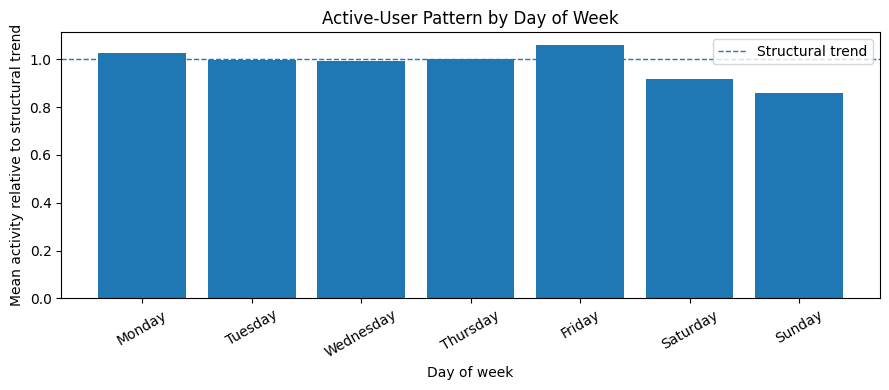

In [13]:
plt.figure(figsize=(9, 4))

plt.bar(
    weekday_active_users_profile.index,
    weekday_active_users_profile["mean"],
)

plt.axhline(
    y=1.0,
    linewidth=1,
    linestyle="--",
    label="Structural trend",
)

plt.title("Active-User Pattern by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Mean activity relative to structural trend")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
EVENT_SPECS = [
    # Promotions
    {
        "start_date": "2023-03-13",
        "duration_days": 3,
        "event_type": "promotion",
        "event_description": "Simulated cashback campaign",
        "expected_direction": "up",
        "event_intensity": 0.10,
    },
    {
        "start_date": "2023-07-10",
        "duration_days": 3,
        "event_type": "promotion",
        "event_description": "Simulated winter promotion",
        "expected_direction": "up",
        "event_intensity": 0.08,
    },
    {
        "start_date": "2023-11-06",
        "duration_days": 4,
        "event_type": "promotion",
        "event_description": "Simulated year-end shopping campaign",
        "expected_direction": "up",
        "event_intensity": 0.15,
    },
    {
        "start_date": "2024-03-11",
        "duration_days": 3,
        "event_type": "promotion",
        "event_description": "Simulated cashback campaign",
        "expected_direction": "up",
        "event_intensity": 0.10,
    },
    {
        "start_date": "2024-07-08",
        "duration_days": 3,
        "event_type": "promotion",
        "event_description": "Simulated winter promotion",
        "expected_direction": "up",
        "event_intensity": 0.09,
    },
    {
        "start_date": "2024-11-04",
        "duration_days": 4,
        "event_type": "promotion",
        "event_description": "Simulated year-end shopping campaign",
        "expected_direction": "up",
        "event_intensity": 0.16,
    },
    {
        "start_date": "2025-03-10",
        "duration_days": 3,
        "event_type": "promotion",
        "event_description": "Simulated cashback campaign",
        "expected_direction": "up",
        "event_intensity": 0.11,
    },
    {
        "start_date": "2025-07-14",
        "duration_days": 3,
        "event_type": "promotion",
        "event_description": "Simulated winter promotion",
        "expected_direction": "up",
        "event_intensity": 0.10,
    },
    {
        "start_date": "2025-11-03",
        "duration_days": 4,
        "event_type": "promotion",
        "event_description": "Simulated year-end shopping campaign",
        "expected_direction": "up",
        "event_intensity": 0.18,
    },
    {
        "start_date": "2026-03-09",
        "duration_days": 3,
        "event_type": "promotion",
        "event_description": "Simulated cashback campaign",
        "expected_direction": "up",
        "event_intensity": 0.12,
    },
    {
        "start_date": "2026-07-13",
        "duration_days": 3,
        "event_type": "promotion",
        "event_description": "Simulated winter promotion",
        "expected_direction": "up",
        "event_intensity": 0.11,
    },

    # System incidents
    {
        "start_date": "2023-05-22",
        "duration_days": 1,
        "event_type": "system_incident",
        "event_description": "Temporary transaction-processing degradation",
        "expected_direction": "down",
        "event_intensity": 0.25,
    },
    {
        "start_date": "2023-10-18",
        "duration_days": 1,
        "event_type": "system_incident",
        "event_description": "Temporary platform outage",
        "expected_direction": "down",
        "event_intensity": 0.40,
    },
    {
        "start_date": "2024-02-07",
        "duration_days": 1,
        "event_type": "system_incident",
        "event_description": "Temporary transaction-processing degradation",
        "expected_direction": "down",
        "event_intensity": 0.20,
    },
    {
        "start_date": "2024-09-26",
        "duration_days": 1,
        "event_type": "system_incident",
        "event_description": "Temporary platform outage",
        "expected_direction": "down",
        "event_intensity": 0.35,
    },
    {
        "start_date": "2025-01-23",
        "duration_days": 1,
        "event_type": "system_incident",
        "event_description": "Temporary transaction-processing degradation",
        "expected_direction": "down",
        "event_intensity": 0.22,
    },
    {
        "start_date": "2025-08-14",
        "duration_days": 1,
        "event_type": "system_incident",
        "event_description": "Temporary platform outage",
        "expected_direction": "down",
        "event_intensity": 0.45,
    },
    {
        "start_date": "2026-04-21",
        "duration_days": 1,
        "event_type": "system_incident",
        "event_description": "Temporary transaction-processing degradation",
        "expected_direction": "down",
        "event_intensity": 0.25,
    },

    # Large merchant settlements
    {
        "start_date": "2023-08-31",
        "duration_days": 1,
        "event_type": "large_merchant_settlement",
        "event_description": "Exceptional merchant settlement",
        "expected_direction": "up",
        "event_intensity": 0.30,
    },
    {
        "start_date": "2024-06-28",
        "duration_days": 1,
        "event_type": "large_merchant_settlement",
        "event_description": "Exceptional merchant settlement",
        "expected_direction": "up",
        "event_intensity": 0.35,
    },
    {
        "start_date": "2025-04-30",
        "duration_days": 1,
        "event_type": "large_merchant_settlement",
        "event_description": "Exceptional merchant settlement",
        "expected_direction": "up",
        "event_intensity": 0.28,
    },
    {
        "start_date": "2025-12-29",
        "duration_days": 1,
        "event_type": "large_merchant_settlement",
        "event_description": "Exceptional year-end merchant settlement",
        "expected_direction": "up",
        "event_intensity": 0.40,
    },
    {
        "start_date": "2026-05-29",
        "duration_days": 1,
        "event_type": "large_merchant_settlement",
        "event_description": "Exceptional merchant settlement",
        "expected_direction": "up",
        "event_intensity": 0.32,
    },
]

event_specs = pd.DataFrame(EVENT_SPECS)
event_specs["start_date"] = pd.to_datetime(event_specs["start_date"])

event_specs.head()

,start_date,duration_days,event_type,event_description,expected_direction,event_intensity
0,2023-03-13,3,promotion,Simulated cashback campaign,up,0.10
1,2023-07-10,3,promotion,Simulated winter promotion,up,0.08
2,2023-11-06,4,promotion,Simulated year-end shopping campaign,up,0.15
3,2024-03-11,3,promotion,Simulated cashback campaign,up,0.10
4,2024-07-08,3,promotion,Simulated winter promotion,up,0.09


In [15]:
expanded_event_rows = []

for event in event_specs.itertuples(index=False):
    for offset in range(event.duration_days):
        expanded_event_rows.append(
            {
                "date": event.start_date + pd.Timedelta(days=offset),
                "event_type": event.event_type,
                "event_description": event.event_description,
                "expected_direction": event.expected_direction,
                "event_intensity": event.event_intensity,
            }
        )

events = (
    pd.DataFrame(expanded_event_rows)
    .sort_values(["date", "event_type"])
    .reset_index(drop=True)
)

# Confirm that all events fall inside the project period
assert events["date"].between(
    daily_data["date"].min(),
    daily_data["date"].max(),
).all(), "At least one event falls outside the dataset period."

events.head(10)

,date,event_type,event_description,expected_direction,event_intensity
0,2023-03-13,promotion,Simulated cashback campaign,up,0.10
1,2023-03-14,promotion,Simulated cashback campaign,up,0.10
2,2023-03-15,promotion,Simulated cashback campaign,up,0.10
3,2023-05-22,system_incident,Temporary transaction-processing degradation,down,0.25
4,2023-07-10,promotion,Simulated winter promotion,up,0.08
5,2023-07-11,promotion,Simulated winter promotion,up,0.08
6,2023-07-12,promotion,Simulated winter promotion,up,0.08
7,2023-08-31,large_merchant_settlement,Exceptional merchant settlement,up,0.30
8,2023-10-18,system_incident,Temporary platform outage,down,0.40
9,2023-11-06,promotion,Simulated year-end shopping campaign,up,0.15


In [16]:
event_summary = (
    events.groupby("event_type")
    .agg(
        number_of_event_days=("date", "count"),
        first_event_date=("date", "min"),
        last_event_date=("date", "max"),
        minimum_intensity=("event_intensity", "min"),
        maximum_intensity=("event_intensity", "max"),
    )
    .reset_index()
)

event_summary

,event_type,number_of_event_days,first_event_date,last_event_date,minimum_intensity,maximum_intensity
0,large_merchant_settlement,5,2023-08-31,2026-05-29,0.28,0.40
1,promotion,36,2023-03-13,2026-07-15,0.08,0.18
2,system_incident,7,2023-05-22,2026-04-21,0.20,0.45


In [26]:
# Event-calendar quality controls

event_date_counts = (
    events.groupby("date")
    .size()
)

event_validation = pd.Series(
    {
        "event_specifications": len(event_specs),

        "expected_event_days": int(
            event_specs["duration_days"].sum()
        ),

        "generated_event_days": len(events),

        "exact_duplicated_rows": int(
            events.duplicated().sum()
        ),

        "duplicated_event_type_per_date": int(
            events.duplicated(
                subset=["date", "event_type"]
            ).sum()
        ),

        "dates_with_multiple_events": int(
            event_date_counts.gt(1).sum()
        ),

        "events_outside_project_period": int(
            (
                ~events["date"].between(
                    daily_data["date"].min(),
                    daily_data["date"].max(),
                )
            ).sum()
        ),

        "invalid_directions": int(
            (
                ~events["expected_direction"].isin(
                    ["up", "down"]
                )
            ).sum()
        ),

        "invalid_intensities": int(
            (
                ~events["event_intensity"].between(
                    0,
                    1,
                    inclusive="neither",
                )
            ).sum()
        ),
    },
    name="value",
).rename_axis("check").reset_index()

event_validation

,check,value
0,event_specifications,23
1,expected_event_days,48
2,generated_event_days,48
3,exact_duplicated_rows,0
4,duplicated_event_type_per_date,0
5,dates_with_multiple_events,0
6,events_outside_project_period,0
7,invalid_directions,0
8,invalid_intensities,0


In [24]:
# Verify that the required tables exist
if "events" not in globals():
    raise NameError(
        "The 'events' table does not exist. "
        "Run the event-definition and event-expansion cells first."
    )

if "daily_data" not in globals():
    raise NameError(
        "The 'daily_data' table does not exist. "
        "Run the calendar and active-user generation cells first."
    )

event_intensity_columns = [
    "promotion_intensity",
    "system_incident_intensity",
    "merchant_settlement_intensity",
]

event_flag_columns = [
    "is_promotion",
    "system_incident",
    "is_large_merchant_settlement",
]

# Convert the long event table into one row per date
event_daily = (
    events.pivot_table(
        index="date",
        columns="event_type",
        values="event_intensity",
        aggfunc="max",
        fill_value=0.0,
    )
    .rename(
        columns={
            "promotion": "promotion_intensity",
            "system_incident": "system_incident_intensity",
            "large_merchant_settlement": (
                "merchant_settlement_intensity"
            ),
        }
    )
    .reset_index()
)

event_daily.columns.name = None

# Guarantee that all expected intensity columns exist
for column in event_intensity_columns:
    if column not in event_daily.columns:
        event_daily[column] = 0.0

event_daily = event_daily[
    ["date"] + event_intensity_columns
]

# Remove previously generated event features so the cell is safe to rerun
columns_to_remove = [
    column
    for column in (
        event_intensity_columns
        + event_flag_columns
        + ["event_count", "has_any_event"]
    )
    if column in daily_data.columns
]

daily_data = daily_data.drop(
    columns=columns_to_remove
)

# Merge event intensities into the daily dataset
daily_data = daily_data.merge(
    event_daily,
    on="date",
    how="left",
    validate="one_to_one",
)

# Dates without events receive zero intensity
daily_data[event_intensity_columns] = (
    daily_data[event_intensity_columns]
    .fillna(0.0)
)

# Binary event indicators
daily_data["is_promotion"] = (
    daily_data["promotion_intensity"]
    .gt(0)
    .astype("int8")
)

daily_data["system_incident"] = (
    daily_data["system_incident_intensity"]
    .gt(0)
    .astype("int8")
)

daily_data["is_large_merchant_settlement"] = (
    daily_data["merchant_settlement_intensity"]
    .gt(0)
    .astype("int8")
)

# Number of simultaneous events on each date
daily_data["event_count"] = (
    daily_data[event_flag_columns]
    .sum(axis=1)
    .astype("int8")
)

daily_data["has_any_event"] = (
    daily_data["event_count"]
    .gt(0)
    .astype("int8")
)

daily_data.loc[
    daily_data["has_any_event"].eq(1),
    [
        "date",
        "is_promotion",
        "promotion_intensity",
        "system_incident",
        "system_incident_intensity",
        "is_large_merchant_settlement",
        "merchant_settlement_intensity",
        "event_count",
    ],
].head(12)

,date,is_promotion,promotion_intensity,system_incident,system_incident_intensity,is_large_merchant_settlement,merchant_settlement_intensity,event_count
71,2023-03-13,1,0.10,0,0.00,0,0.0,1
72,2023-03-14,1,0.10,0,0.00,0,0.0,1
73,2023-03-15,1,0.10,0,0.00,0,0.0,1
141,2023-05-22,0,0.00,1,0.25,0,0.0,1
190,2023-07-10,1,0.08,0,0.00,0,0.0,1
191,2023-07-11,1,0.08,0,0.00,0,0.0,1
192,2023-07-12,1,0.08,0,0.00,0,0.0,1
242,2023-08-31,0,0.00,0,0.00,1,0.3,1
290,2023-10-18,0,0.00,1,0.40,0,0.0,1
309,2023-11-06,1,0.15,0,0.00,0,0.0,1


In [29]:
# Quality controls after merging event features into daily_data

event_intensity_columns = [
    "promotion_intensity",
    "system_incident_intensity",
    "merchant_settlement_intensity",
]

event_flag_columns = [
    "is_promotion",
    "system_incident",
    "is_large_merchant_settlement",
]

required_event_columns = (
    event_intensity_columns
    + event_flag_columns
    + ["event_count", "has_any_event"]
)

missing_columns = [
    column
    for column in required_event_columns
    if column not in daily_data.columns
]

if missing_columns:
    raise KeyError(
        "The following event columns are missing from daily_data: "
        f"{missing_columns}. Run the event merge cell first."
    )

event_feature_checks = pd.Series(
    {
        "daily_data_rows": len(daily_data),

        "duplicated_dates": int(
            daily_data["date"].duplicated().sum()
        ),

        "missing_event_values": int(
            daily_data[required_event_columns]
            .isna()
            .sum()
            .sum()
        ),

        "promotion_days": int(
            daily_data["is_promotion"].sum()
        ),

        "system_incident_days": int(
            daily_data["system_incident"].sum()
        ),

        "merchant_settlement_days": int(
            daily_data[
                "is_large_merchant_settlement"
            ].sum()
        ),

        "days_with_any_event": int(
            daily_data["has_any_event"].sum()
        ),

        "days_with_multiple_events": int(
            daily_data["event_count"]
            .gt(1)
            .sum()
        ),

        "maximum_events_on_one_day": int(
            daily_data["event_count"].max()
        ),

        "negative_event_intensities": int(
            (
                daily_data[event_intensity_columns] < 0
            )
            .sum()
            .sum()
        ),
    },
    name="value",
).rename_axis("check").reset_index()

event_feature_checks


,check,value
0,daily_data_rows,1308
1,duplicated_dates,0
2,missing_event_values,0
3,promotion_days,36
4,system_incident_days,7
5,merchant_settlement_days,5
6,days_with_any_event,48
7,days_with_multiple_events,0
8,maximum_events_on_one_day,1
9,negative_event_intensities,0


In [30]:
# Final validation of event features

assert len(daily_data) == 1308, (
    "The merge changed the number of daily observations."
)

assert daily_data["date"].duplicated().sum() == 0, (
    "Duplicated dates were created during the merge."
)

assert daily_data[required_event_columns].isna().sum().sum() == 0, (
    "Missing values were detected in the event features."
)

assert daily_data["is_promotion"].sum() == 36, (
    "The number of promotion days is incorrect."
)

assert daily_data["system_incident"].sum() == 7, (
    "The number of system-incident days is incorrect."
)

assert daily_data["is_large_merchant_settlement"].sum() == 5, (
    "The number of merchant-settlement days is incorrect."
)

assert daily_data["has_any_event"].sum() == 48, (
    "The number of days containing events is incorrect."
)

assert daily_data["event_count"].gt(1).sum() == 0, (
    "Unexpected overlapping events were detected."
)

assert (
    daily_data[event_intensity_columns] < 0
).sum().sum() == 0, (
    "Negative event intensities were detected."
)

print("Event-feature merge validation passed successfully.")

Event-feature merge validation passed successfully.


## Synthetic Transaction Counts

Daily withdrawal and outgoing-transfer counts are generated from the number
of active users and their expected transaction propensity.

The data-generating process includes:

- Channel-specific weekly transaction patterns.
- Payday-window effects.
- Month-end effects.
- Holiday effects.
- Promotional campaigns.
- System incidents.
- A shared stochastic demand component.
- Channel-specific random variability.

Large merchant settlements are not applied to transaction counts because they
represent exceptional high-value transfers rather than a general increase in
the number of transactions.

Internal columns beginning with `_expected_` are retained temporarily for
quality control and will be removed before saving the modeling dataset.

In [31]:
# Required inputs for transaction-count generation
required_count_inputs = [
    "date",
    "active_users",
    "day_of_week",
    "is_payday_window",
    "is_month_end",
    "is_holiday",
    "promotion_intensity",
    "system_incident_intensity",
]

missing_count_inputs = [
    column
    for column in required_count_inputs
    if column not in daily_data.columns
]

if missing_count_inputs:
    raise KeyError(
        "The following columns are required before generating "
        f"transaction counts: {missing_count_inputs}"
    )


TRANSACTION_COUNT_CONFIG = {
    # Expected transactions per active user on a regular day
    "base_withdrawal_rate": 0.085,
    "base_transfer_rate": 0.210,

    # Calendar effects
    "withdrawal_payday_effect": 0.16,
    "transfer_payday_effect": 0.24,
    "withdrawal_month_end_effect": 0.06,
    "transfer_month_end_effect": 0.14,
    "withdrawal_holiday_effect": -0.08,
    "transfer_holiday_effect": -0.16,

    # Promotion intensity multipliers
    "withdrawal_promotion_weight": 0.50,
    "transfer_promotion_weight": 1.00,

    # Random variability
    "shared_demand_sigma": 0.055,
    "withdrawal_specific_sigma": 0.030,
    "transfer_specific_sigma": 0.035,
}

# Dedicated seed for this part of the generator
count_rng = np.random.default_rng(
    PROJECT_CONFIG["random_seed"] + 2
)


def generate_mean_one_lognormal(
    rng,
    sigma,
    size,
):
    """
    Generate positive multiplicative noise with an expected value of one.
    """
    return np.exp(
        rng.normal(
            loc=-0.5 * sigma**2,
            scale=sigma,
            size=size,
        )
    )


# Channel-specific transaction propensity by weekday.
# The weekly pattern already present in active_users is preserved,
# while these factors represent additional channel behavior.
withdrawal_weekday_factor = {
    0: 0.96,  # Monday
    1: 0.98,  # Tuesday
    2: 1.00,  # Wednesday
    3: 1.02,  # Thursday
    4: 1.08,  # Friday
    5: 1.12,  # Saturday
    6: 0.95,  # Sunday
}

transfer_weekday_factor = {
    0: 1.08,  # Monday
    1: 1.02,  # Tuesday
    2: 1.00,  # Wednesday
    3: 1.03,  # Thursday
    4: 1.10,  # Friday
    5: 0.72,  # Saturday
    6: 0.60,  # Sunday
}

withdrawal_weekday_multiplier = (
    daily_data["day_of_week"]
    .map(withdrawal_weekday_factor)
    .to_numpy()
)

transfer_weekday_multiplier = (
    daily_data["day_of_week"]
    .map(transfer_weekday_factor)
    .to_numpy()
)


# Calendar effects
withdrawal_calendar_multiplier = (
    (
        1
        + TRANSACTION_COUNT_CONFIG["withdrawal_payday_effect"]
        * daily_data["is_payday_window"]
    )
    * (
        1
        + TRANSACTION_COUNT_CONFIG["withdrawal_month_end_effect"]
        * daily_data["is_month_end"]
    )
    * (
        1
        + TRANSACTION_COUNT_CONFIG["withdrawal_holiday_effect"]
        * daily_data["is_holiday"]
    )
)

transfer_calendar_multiplier = (
    (
        1
        + TRANSACTION_COUNT_CONFIG["transfer_payday_effect"]
        * daily_data["is_payday_window"]
    )
    * (
        1
        + TRANSACTION_COUNT_CONFIG["transfer_month_end_effect"]
        * daily_data["is_month_end"]
    )
    * (
        1
        + TRANSACTION_COUNT_CONFIG["transfer_holiday_effect"]
        * daily_data["is_holiday"]
    )
)


# Event effects
withdrawal_event_multiplier = (
    (
        1
        + TRANSACTION_COUNT_CONFIG["withdrawal_promotion_weight"]
        * daily_data["promotion_intensity"]
    )
    * (
        1
        - daily_data["system_incident_intensity"]
    )
)

transfer_event_multiplier = (
    (
        1
        + TRANSACTION_COUNT_CONFIG["transfer_promotion_weight"]
        * daily_data["promotion_intensity"]
    )
    * (
        1
        - daily_data["system_incident_intensity"]
    )
)


# Shared demand variation creates realistic co-movement between channels
shared_demand_shock = generate_mean_one_lognormal(
    rng=count_rng,
    sigma=TRANSACTION_COUNT_CONFIG["shared_demand_sigma"],
    size=len(daily_data),
)

withdrawal_specific_shock = generate_mean_one_lognormal(
    rng=count_rng,
    sigma=TRANSACTION_COUNT_CONFIG["withdrawal_specific_sigma"],
    size=len(daily_data),
)

transfer_specific_shock = generate_mean_one_lognormal(
    rng=count_rng,
    sigma=TRANSACTION_COUNT_CONFIG["transfer_specific_sigma"],
    size=len(daily_data),
)


# Expected daily counts used only for generator validation
daily_data["_expected_withdrawal_count"] = (
    daily_data["active_users"]
    * TRANSACTION_COUNT_CONFIG["base_withdrawal_rate"]
    * withdrawal_weekday_multiplier
    * withdrawal_calendar_multiplier
    * withdrawal_event_multiplier
    * shared_demand_shock
    * withdrawal_specific_shock
)

daily_data["_expected_transfer_count"] = (
    daily_data["active_users"]
    * TRANSACTION_COUNT_CONFIG["base_transfer_rate"]
    * transfer_weekday_multiplier
    * transfer_calendar_multiplier
    * transfer_event_multiplier
    * shared_demand_shock
    * transfer_specific_shock
)


# Draw integer counts from Poisson distributions
daily_data["withdrawal_count"] = count_rng.poisson(
    lam=np.clip(
        daily_data["_expected_withdrawal_count"],
        a_min=1,
        a_max=None,
    )
).astype("int64")

daily_data["transfer_count"] = count_rng.poisson(
    lam=np.clip(
        daily_data["_expected_transfer_count"],
        a_min=1,
        a_max=None,
    )
).astype("int64")

daily_data[
    [
        "date",
        "active_users",
        "withdrawal_count",
        "transfer_count",
        "is_payday_window",
        "is_holiday",
        "is_promotion",
        "system_incident",
    ]
].head(10)

,date,active_users,withdrawal_count,transfer_count,is_payday_window,is_holiday,is_promotion,system_incident
0,2023-01-01,34610,2695,3938,0,1,0,0
1,2023-01-02,41919,3987,12030,1,0,0,0
2,2023-01-03,39454,3787,10580,1,0,0,0
3,2023-01-04,38758,4028,10263,1,0,0,0
4,2023-01-05,38084,3614,8968,0,0,0,0
5,2023-01-06,43538,3991,10636,0,0,0,0
6,2023-01-07,36926,3449,5612,0,0,0,0
7,2023-01-08,34698,2442,4002,0,0,0,0
8,2023-01-09,40555,3425,9162,0,0,0,0
9,2023-01-10,41412,3371,8201,0,0,0,0


In [32]:
transaction_count_checks = pd.DataFrame(
    [
        {
            "variable": column,
            "dtype": str(daily_data[column].dtype),
            "missing_values": int(
                daily_data[column].isna().sum()
            ),
            "negative_values": int(
                daily_data[column].lt(0).sum()
            ),
            "zero_values": int(
                daily_data[column].eq(0).sum()
            ),
            "minimum": int(
                daily_data[column].min()
            ),
            "p05": round(
                daily_data[column].quantile(0.05),
                1,
            ),
            "median": round(
                daily_data[column].median(),
                1,
            ),
            "mean": round(
                daily_data[column].mean(),
                1,
            ),
            "p95": round(
                daily_data[column].quantile(0.95),
                1,
            ),
            "maximum": int(
                daily_data[column].max()
            ),
            "first_30_days_mean": round(
                daily_data[column].head(30).mean(),
                1,
            ),
            "last_30_days_mean": round(
                daily_data[column].tail(30).mean(),
                1,
            ),
            "mean_per_active_user": round(
                (
                    daily_data[column]
                    / daily_data["active_users"]
                ).mean(),
                4,
            ),
        }
        for column in [
            "withdrawal_count",
            "transfer_count",
        ]
    ]
)

transaction_count_checks

,variable,dtype,missing_values,negative_values,zero_values,minimum,p05,median,mean,p95,maximum,first_30_days_mean,last_30_days_mean,mean_per_active_user
0,withdrawal_count,int64,0,0,0,2391,3305.2,4812.5,4914.6,6792.4,8845,3538.5,6595.7,0.0889
1,transfer_count,int64,0,0,0,3676,5493.8,11424.5,11528.0,18043.4,24887,8123.9,15571.7,0.2061


In [33]:
# General relationship checks for transaction counts

transaction_relationship_checks = pd.Series(
    {
        "withdrawal_mean_per_active_user": round(
            (
                daily_data["withdrawal_count"]
                / daily_data["active_users"]
            ).mean(),
            4,
        ),

        "transfer_mean_per_active_user": round(
            (
                daily_data["transfer_count"]
                / daily_data["active_users"]
            ).mean(),
            4,
        ),

        "withdrawal_active_users_correlation": round(
            daily_data[
                ["withdrawal_count", "active_users"]
            ]
            .corr()
            .iloc[0, 1],
            3,
        ),

        "transfer_active_users_correlation": round(
            daily_data[
                ["transfer_count", "active_users"]
            ]
            .corr()
            .iloc[0, 1],
            3,
        ),

        "count_channels_correlation": round(
            daily_data[
                ["withdrawal_count", "transfer_count"]
            ]
            .corr()
            .iloc[0, 1],
            3,
        ),

        "days_transfers_exceed_withdrawals": round(
            daily_data["transfer_count"]
            .gt(daily_data["withdrawal_count"])
            .mean(),
            3,
        ),

        "withdrawal_last_to_first_30d_ratio": round(
            daily_data["withdrawal_count"]
            .tail(30)
            .mean()
            / daily_data["withdrawal_count"]
            .head(30)
            .mean(),
            3,
        ),

        "transfer_last_to_first_30d_ratio": round(
            daily_data["transfer_count"]
            .tail(30)
            .mean()
            / daily_data["transfer_count"]
            .head(30)
            .mean(),
            3,
        ),
    },
    name="value",
).rename_axis("check").reset_index()

transaction_relationship_checks

,check,value
0,withdrawal_mean_per_active_user,0.0889
1,transfer_mean_per_active_user,0.2061
2,withdrawal_active_users_correlation,0.8840
3,transfer_active_users_correlation,0.7520
4,count_channels_correlation,0.8100
5,days_transfers_exceed_withdrawals,1.0000
6,withdrawal_last_to_first_30d_ratio,1.8640
7,transfer_last_to_first_30d_ratio,1.9170


In [34]:
# Normalize counts by active users and channel-specific weekday patterns

daily_data["_withdrawal_normalized_rate"] = (
    daily_data["withdrawal_count"]
    / (
        daily_data["active_users"]
        * daily_data["day_of_week"].map(
            withdrawal_weekday_factor
        )
    )
)

daily_data["_transfer_normalized_rate"] = (
    daily_data["transfer_count"]
    / (
        daily_data["active_users"]
        * daily_data["day_of_week"].map(
            transfer_weekday_factor
        )
    )
)


def no_other_effects(
    exclude_payday=False,
    exclude_month_end=False,
    exclude_holiday=False,
    exclude_promotion=False,
    exclude_incident=False,
):
    """
    Build a mask excluding calendar and event effects that could
    confound the comparison.
    """
    mask = pd.Series(True, index=daily_data.index)

    if exclude_payday:
        mask &= daily_data["is_payday_window"].eq(0)

    if exclude_month_end:
        mask &= daily_data["is_month_end"].eq(0)

    if exclude_holiday:
        mask &= daily_data["is_holiday"].eq(0)

    if exclude_promotion:
        mask &= daily_data["promotion_intensity"].eq(0)

    if exclude_incident:
        mask &= daily_data["system_incident_intensity"].eq(0)

    return mask


# Regular days without calendar or event effects
baseline_mask = no_other_effects(
    exclude_payday=True,
    exclude_month_end=True,
    exclude_holiday=True,
    exclude_promotion=True,
    exclude_incident=True,
)

effect_masks = {
    "baseline": baseline_mask,

    "payday_window": (
        daily_data["is_payday_window"].eq(1)
        & no_other_effects(
            exclude_month_end=True,
            exclude_holiday=True,
            exclude_promotion=True,
            exclude_incident=True,
        )
    ),

    "month_end": (
        daily_data["is_month_end"].eq(1)
        & no_other_effects(
            exclude_payday=True,
            exclude_holiday=True,
            exclude_promotion=True,
            exclude_incident=True,
        )
    ),

    "holiday": (
        daily_data["is_holiday"].eq(1)
        & no_other_effects(
            exclude_payday=True,
            exclude_month_end=True,
            exclude_promotion=True,
            exclude_incident=True,
        )
    ),

    "promotion": (
        daily_data["promotion_intensity"].gt(0)
        & no_other_effects(
            exclude_payday=True,
            exclude_month_end=True,
            exclude_holiday=True,
            exclude_incident=True,
        )
    ),

    "system_incident": (
        daily_data["system_incident_intensity"].gt(0)
        & no_other_effects(
            exclude_payday=True,
            exclude_month_end=True,
            exclude_holiday=True,
            exclude_promotion=True,
        )
    ),
}


baseline_withdrawal_rate = daily_data.loc[
    baseline_mask,
    "_withdrawal_normalized_rate",
].mean()

baseline_transfer_rate = daily_data.loc[
    baseline_mask,
    "_transfer_normalized_rate",
].mean()


effect_validation_rows = []

for effect_name, mask in effect_masks.items():
    effect_validation_rows.append(
        {
            "effect": effect_name,
            "number_of_days": int(mask.sum()),

            "withdrawal_ratio_vs_baseline": round(
                daily_data.loc[
                    mask,
                    "_withdrawal_normalized_rate",
                ].mean()
                / baseline_withdrawal_rate,
                3,
            ),

            "transfer_ratio_vs_baseline": round(
                daily_data.loc[
                    mask,
                    "_transfer_normalized_rate",
                ].mean()
                / baseline_transfer_rate,
                3,
            ),
        }
    )

transaction_effect_checks = pd.DataFrame(
    effect_validation_rows
)

transaction_effect_checks

,effect,number_of_days,withdrawal_ratio_vs_baseline,transfer_ratio_vs_baseline
0,baseline,907,1.000,1.000
1,payday_window,243,1.157,1.236
2,month_end,43,1.054,1.141
3,holiday,65,0.925,0.843
4,promotion,28,1.067,1.119
5,system_incident,6,0.738,0.743


## Synthetic Macroeconomic Variables

The synthetic macroeconomic environment represents an ARS-denominated
Fintech operation but does not reproduce the historical economy of Argentina.

The generated variables are:

- `exchange_rate`: synthetic ARS per USD exchange rate.
- `exchange_rate_change`: daily percentage change.
- `exchange_rate_volatility`: 21-day annualized volatility.
- `interest_rate`: synthetic annual nominal interest rate.
- `macro_shock_intensity`: documented exceptional exchange-rate movements.

The exchange rate follows a stochastic log process with persistent daily
variation and a small number of predefined macroeconomic shocks.

These variables describe the data-generating environment. During forecasting,
future observed values will not be used unless they are explicitly available
at the forecast origin or incorporated through a documented scenario.

In [39]:
# Required inputs for synthetic macroeconomic variables

required_macro_inputs = [
    "date",
]

missing_macro_inputs = [
    column
    for column in required_macro_inputs
    if column not in daily_data.columns
]

if missing_macro_inputs:
    raise KeyError(
        "The following columns are required before generating "
        f"macroeconomic variables: {missing_macro_inputs}"
    )


# ---------------------------------------------------------
# Macroeconomic configuration
# ---------------------------------------------------------

MACRO_CONFIG = {
    "initial_exchange_rate": 180.0,
    "base_daily_log_depreciation": 0.00115,
    "shock_persistence": 0.70,
    "daily_innovation_std": 0.0035,
    "volatility_window_days": 21,
    "initial_interest_rate": 0.48,
    "interest_rate_adjustment_speed": 0.025,
    "interest_rate_noise_std": 0.0012,
}


# ---------------------------------------------------------
# Documented synthetic macroeconomic shocks
# ---------------------------------------------------------

MACRO_SHOCK_SPECS = [
    {
        "date": "2023-08-14",
        "shock_intensity": 0.055,
        "description": "Synthetic exchange-rate repricing",
    },
    {
        "date": "2024-12-18",
        "shock_intensity": 0.045,
        "description": "Synthetic macroeconomic uncertainty shock",
    },
    {
        "date": "2025-06-02",
        "shock_intensity": 0.060,
        "description": "Synthetic exchange-rate repricing",
    },
    {
        "date": "2026-03-16",
        "shock_intensity": 0.040,
        "description": "Synthetic macroeconomic uncertainty shock",
    },
]

macro_shocks = pd.DataFrame(MACRO_SHOCK_SPECS)
macro_shocks["date"] = pd.to_datetime(
    macro_shocks["date"]
)


# ---------------------------------------------------------
# Validate macroeconomic shock definitions
# ---------------------------------------------------------

assert macro_shocks["date"].between(
    daily_data["date"].min(),
    daily_data["date"].max(),
).all(), (
    "At least one macro shock falls outside the project period."
)

assert macro_shocks["date"].duplicated().sum() == 0, (
    "Duplicated macro-shock dates were detected."
)

assert macro_shocks["shock_intensity"].gt(0).all(), (
    "Macro-shock intensities must be positive."
)


# ---------------------------------------------------------
# Dedicated random generators
# ---------------------------------------------------------

macro_rng = np.random.default_rng(
    PROJECT_CONFIG["random_seed"] + 3
)

interest_rate_rng = np.random.default_rng(
    PROJECT_CONFIG["random_seed"] + 30
)

number_of_days = len(daily_data)
time_index = np.arange(number_of_days)


# ---------------------------------------------------------
# Persistent stochastic exchange-rate component
# ---------------------------------------------------------

macro_innovations = macro_rng.normal(
    loc=0.0,
    scale=MACRO_CONFIG["daily_innovation_std"],
    size=number_of_days,
)

persistent_macro_component = np.zeros(
    number_of_days,
    dtype=float,
)

for index in range(1, number_of_days):
    persistent_macro_component[index] = (
        MACRO_CONFIG["shock_persistence"]
        * persistent_macro_component[index - 1]
        + macro_innovations[index]
    )


# ---------------------------------------------------------
# Mild annual variation in the depreciation process
# ---------------------------------------------------------

cyclical_depreciation_component = (
    0.00020
    * np.sin(
        2
        * np.pi
        * time_index
        / 365.25
    )
)


# ---------------------------------------------------------
# Map documented shocks to the daily dataset
# ---------------------------------------------------------

macro_shock_intensity_map = (
    macro_shocks
    .set_index("date")["shock_intensity"]
)

macro_shock_description_map = (
    macro_shocks
    .set_index("date")["description"]
)

daily_data["macro_shock_intensity"] = (
    daily_data["date"]
    .map(macro_shock_intensity_map)
    .fillna(0.0)
)

daily_data["macro_shock_description"] = (
    daily_data["date"]
    .map(macro_shock_description_map)
)

daily_data["is_macro_shock"] = (
    daily_data["macro_shock_intensity"]
    .gt(0)
    .astype("int8")
)


# ---------------------------------------------------------
# Daily synthetic exchange-rate changes
# ---------------------------------------------------------

daily_log_exchange_rate_change = (
    MACRO_CONFIG["base_daily_log_depreciation"]
    + cyclical_depreciation_component
    + persistent_macro_component
    + daily_data[
        "macro_shock_intensity"
    ].to_numpy()
)


# ---------------------------------------------------------
# Synthetic exchange-rate path
# ---------------------------------------------------------

exchange_rate_path = np.empty(
    number_of_days,
    dtype=float,
)

# The first observation is exactly the configured initial value
exchange_rate_path[0] = (
    MACRO_CONFIG["initial_exchange_rate"]
)

# Daily changes are accumulated from the second observation onward
exchange_rate_path[1:] = (
    MACRO_CONFIG["initial_exchange_rate"]
    * np.exp(
        np.cumsum(
            daily_log_exchange_rate_change[1:]
        )
    )
)

daily_data["exchange_rate"] = (
    exchange_rate_path
)

daily_data["exchange_rate_change"] = (
    daily_data["exchange_rate"]
    .pct_change()
    .fillna(0.0)
)


# ---------------------------------------------------------
# Rolling exchange-rate volatility
# ---------------------------------------------------------

exchange_rate_log_return = (
    np.log(
        daily_data["exchange_rate"]
    )
    .diff()
    .fillna(0.0)
)

daily_data["exchange_rate_volatility"] = (
    exchange_rate_log_return
    .rolling(
        window=MACRO_CONFIG[
            "volatility_window_days"
        ],
        min_periods=2,
    )
    .std()
    * np.sqrt(365)
)

daily_data["exchange_rate_volatility"] = (
    daily_data["exchange_rate_volatility"]
    .fillna(0.0)
)


# ---------------------------------------------------------
# Smooth synthetic interest-rate process
# ---------------------------------------------------------

# Use the configured depreciation rate for the first observation
# so the initial estimate is not artificially equal to zero.
exchange_rate_return_for_interest = (
    exchange_rate_log_return.copy()
)

exchange_rate_return_for_interest.iloc[0] = (
    MACRO_CONFIG[
        "base_daily_log_depreciation"
    ]
)

# Trailing annualized depreciation estimate.
# Only current and previous observations are used.
smoothed_annualized_depreciation = (
    exchange_rate_return_for_interest
    .rolling(
        window=90,
        min_periods=1,
    )
    .mean()
    * 365
)

smoothed_annualized_depreciation = (
    smoothed_annualized_depreciation
    .ewm(
        span=30,
        adjust=False,
    )
    .mean()
    .clip(
        lower=0.0,
        upper=1.50,
    )
)

smoothed_exchange_rate_volatility = (
    daily_data["exchange_rate_volatility"]
    .ewm(
        span=60,
        adjust=False,
    )
    .mean()
)

# Long-run synthetic rate implied by depreciation and volatility
target_interest_rate = (
    0.25
    + 0.45
    * smoothed_annualized_depreciation
    + 0.25
    * smoothed_exchange_rate_volatility
).clip(
    lower=0.28,
    upper=0.90,
)

interest_rate_noise = (
    interest_rate_rng.normal(
        loc=0.0,
        scale=MACRO_CONFIG[
            "interest_rate_noise_std"
        ],
        size=number_of_days,
    )
)

interest_rate_path = np.empty(
    number_of_days,
    dtype=float,
)

interest_rate_path[0] = (
    MACRO_CONFIG["initial_interest_rate"]
)

for index in range(1, number_of_days):
    previous_rate = (
        interest_rate_path[index - 1]
    )

    current_target = (
        target_interest_rate.iloc[index]
    )

    interest_rate_path[index] = (
        previous_rate
        + MACRO_CONFIG[
            "interest_rate_adjustment_speed"
        ]
        * (
            current_target
            - previous_rate
        )
        + interest_rate_noise[index]
    )

daily_data["interest_rate"] = (
    pd.Series(
        interest_rate_path,
        index=daily_data.index,
    )
    .ewm(
        span=5,
        adjust=False,
    )
    .mean()
    .clip(
        lower=0.25,
        upper=0.95,
    )
)


# ---------------------------------------------------------
# Preview
# ---------------------------------------------------------

daily_data[
    [
        "date",
        "exchange_rate",
        "exchange_rate_change",
        "exchange_rate_volatility",
        "interest_rate",
        "is_macro_shock",
        "macro_shock_intensity",
        "macro_shock_description",
    ]
].head(10)

,date,exchange_rate,exchange_rate_change,exchange_rate_volatility,interest_rate,is_macro_shock,macro_shock_intensity,macro_shock_description
0,2023-01-01,180.000000,0.000000,0.000000,0.480000,0,0.0,NaN
1,2023-01-02,179.815313,-0.001026,0.013868,0.479551,0,0.0,NaN
2,2023-01-03,179.834085,0.000104,0.011941,0.478971,0,0.0,NaN
3,2023-01-04,180.442454,0.003383,0.036523,0.477395,0,0.0,NaN
4,2023-01-05,180.839113,0.002198,0.034397,0.475316,0,0.0,NaN
5,2023-01-06,181.347685,0.002812,0.034075,0.473142,0,0.0,NaN
6,2023-01-07,182.107352,0.004189,0.037648,0.471780,0,0.0,NaN
7,2023-01-08,183.147431,0.005711,0.044235,0.471111,0,0.0,NaN
8,2023-01-09,183.371108,0.001221,0.041815,0.470674,0,0.0,NaN
9,2023-01-10,183.894809,0.002856,0.039711,0.470533,0,0.0,NaN


In [40]:
macro_variable_checks = pd.Series(
    {
        "missing_values": int(
            daily_data[
                [
                    "exchange_rate",
                    "exchange_rate_change",
                    "exchange_rate_volatility",
                    "interest_rate",
                    "macro_shock_intensity",
                ]
            ]
            .isna()
            .sum()
            .sum()
        ),

        "non_positive_exchange_rates": int(
            daily_data["exchange_rate"]
            .le(0)
            .sum()
        ),

        "negative_volatility_values": int(
            daily_data["exchange_rate_volatility"]
            .lt(0)
            .sum()
        ),

        "initial_exchange_rate": round(
            daily_data["exchange_rate"].iloc[0],
            2,
        ),

        "final_exchange_rate": round(
            daily_data["exchange_rate"].iloc[-1],
            2,
        ),

        "minimum_exchange_rate": round(
            daily_data["exchange_rate"].min(),
            2,
        ),

        "maximum_exchange_rate": round(
            daily_data["exchange_rate"].max(),
            2,
        ),

        "minimum_interest_rate": round(
            daily_data["interest_rate"].min(),
            3,
        ),

        "maximum_interest_rate": round(
            daily_data["interest_rate"].max(),
            3,
        ),

        "mean_interest_rate": round(
            daily_data["interest_rate"].mean(),
            3,
        ),

        "maximum_exchange_rate_volatility": round(
            daily_data["exchange_rate_volatility"].max(),
            3,
        ),

        "macro_shock_days": int(
            daily_data["is_macro_shock"].sum()
        ),
    },
    name="value",
).rename_axis("check").reset_index()

macro_variable_checks

,check,value
0,missing_values,0.000
1,non_positive_exchange_rates,0.000
2,negative_volatility_values,0.000
3,initial_exchange_rate,180.000
4,final_exchange_rate,783.830
5,minimum_exchange_rate,166.950
6,maximum_exchange_rate,799.250
7,minimum_interest_rate,0.286
8,maximum_interest_rate,0.678
9,mean_interest_rate,0.470


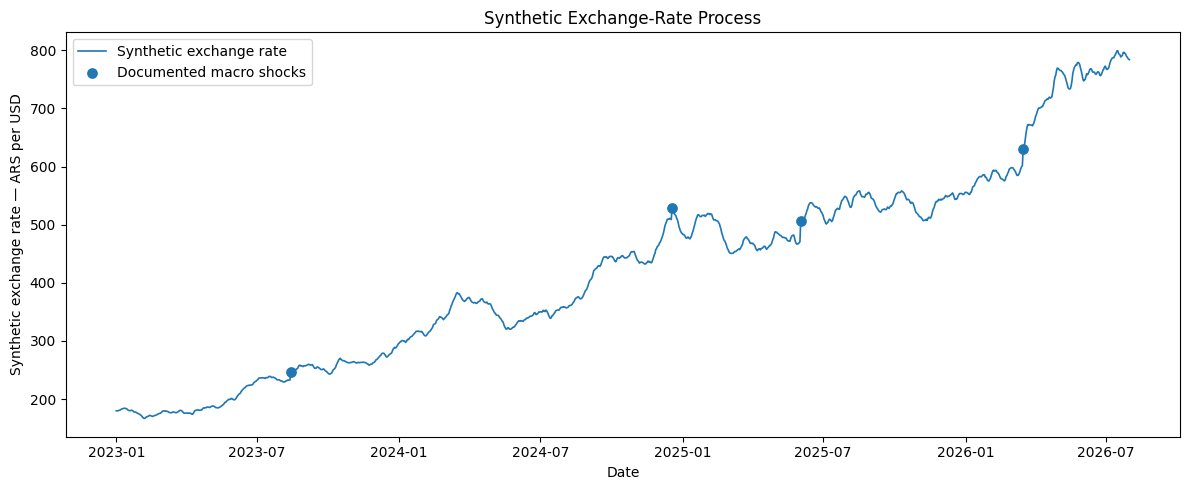

In [41]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_data["date"],
    daily_data["exchange_rate"],
    linewidth=1.2,
    label="Synthetic exchange rate",
)

macro_shock_dates = daily_data.loc[
    daily_data["is_macro_shock"].eq(1),
    "date",
]

macro_shock_values = daily_data.loc[
    daily_data["is_macro_shock"].eq(1),
    "exchange_rate",
]

plt.scatter(
    macro_shock_dates,
    macro_shock_values,
    s=45,
    label="Documented macro shocks",
)

plt.title("Synthetic Exchange-Rate Process")
plt.xlabel("Date")
plt.ylabel("Synthetic exchange rate — ARS per USD")
plt.legend()
plt.tight_layout()
plt.show()

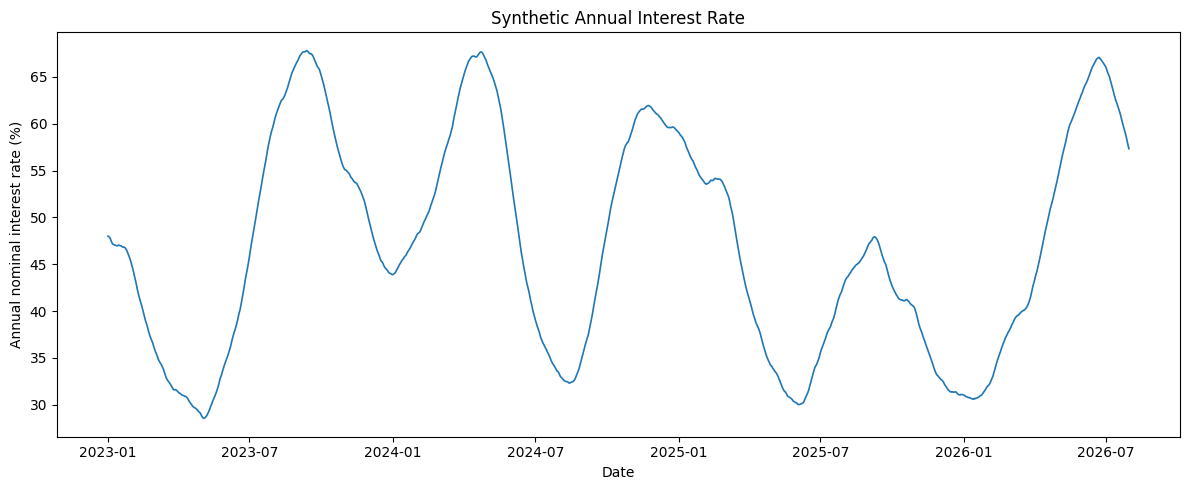

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_data["date"],
    daily_data["interest_rate"] * 100,
    linewidth=1.2,
)

plt.title("Synthetic Annual Interest Rate")
plt.xlabel("Date")
plt.ylabel("Annual nominal interest rate (%)")
plt.tight_layout()
plt.show()

## Average Transaction Tickets and Daily Cash Outflows

Average transaction tickets are generated in nominal ARS and depend on:

- The synthetic exchange-rate environment.
- Calendar effects.
- Payday and month-end behavior.
- Promotional campaigns.
- Exchange-rate shocks and volatility.
- Channel-specific stochastic variation.
- Exceptional merchant settlements.

Daily aggregated amounts are expressed in **ARS millions**:

$$
\text{withdrawal\_amount}
=
\frac{
\text{withdrawal\_count}
\times
\text{average\_withdrawal\_ticket}
}{
10^6
}
$$

$$
\text{outgoing\_transfer\_amount}
=
\frac{
\text{transfer\_count}
\times
\text{average\_transfer\_ticket}
}{
10^6
}
$$

The final forecasting target is:

$$
\text{total\_cash\_outflow}
=
\text{withdrawal\_amount}
+
\text{outgoing\_transfer\_amount}
$$

In [43]:
# Required inputs for ticket and amount generation

required_amount_inputs = [
    "date",
    "withdrawal_count",
    "transfer_count",
    "exchange_rate",
    "exchange_rate_volatility",
    "macro_shock_intensity",
    "is_payday_window",
    "is_month_end",
    "promotion_intensity",
    "merchant_settlement_intensity",
]

missing_amount_inputs = [
    column
    for column in required_amount_inputs
    if column not in daily_data.columns
]

if missing_amount_inputs:
    raise KeyError(
        "The following columns are required before generating "
        f"transaction tickets and amounts: {missing_amount_inputs}"
    )


TICKET_CONFIG = {
    # Nominal ARS per transaction at the beginning of the dataset
    "initial_withdrawal_ticket": 32_000.0,
    "initial_transfer_ticket": 21_000.0,

    # Partial nominal adjustment to the exchange-rate environment
    "withdrawal_exchange_rate_elasticity": 0.55,
    "transfer_exchange_rate_elasticity": 0.48,

    # Calendar effects
    "withdrawal_payday_effect": 0.07,
    "transfer_payday_effect": 0.05,
    "withdrawal_month_end_effect": 0.04,
    "transfer_month_end_effect": 0.08,

    # Promotion effects
    "withdrawal_promotion_weight": 0.25,
    "transfer_promotion_weight": 0.45,

    # Macroeconomic sensitivity
    "withdrawal_volatility_weight": 0.20,
    "transfer_volatility_weight": 0.45,
    "withdrawal_macro_shock_weight": 1.50,
    "transfer_macro_shock_weight": 3.00,

    # Large merchant settlements affect transfer size
    "merchant_settlement_weight": 2.50,

    # Daily multiplicative noise
    "shared_ticket_sigma": 0.025,
    "withdrawal_ticket_sigma": 0.035,
    "transfer_ticket_sigma": 0.045,
}

ticket_rng = np.random.default_rng(
    PROJECT_CONFIG["random_seed"] + 4
)

initial_exchange_rate = TICKET_CONFIG.get(
    "reference_exchange_rate",
    MACRO_CONFIG["initial_exchange_rate"],
)

# Nominal scaling is slower than the exchange-rate growth itself
exchange_rate_ratio = (
    daily_data["exchange_rate"]
    / initial_exchange_rate
)

withdrawal_nominal_scaling = (
    exchange_rate_ratio
    ** TICKET_CONFIG[
        "withdrawal_exchange_rate_elasticity"
    ]
)

transfer_nominal_scaling = (
    exchange_rate_ratio
    ** TICKET_CONFIG[
        "transfer_exchange_rate_elasticity"
    ]
)


# Calendar multipliers
withdrawal_ticket_calendar_multiplier = (
    (
        1
        + TICKET_CONFIG["withdrawal_payday_effect"]
        * daily_data["is_payday_window"]
    )
    * (
        1
        + TICKET_CONFIG["withdrawal_month_end_effect"]
        * daily_data["is_month_end"]
    )
)

transfer_ticket_calendar_multiplier = (
    (
        1
        + TICKET_CONFIG["transfer_payday_effect"]
        * daily_data["is_payday_window"]
    )
    * (
        1
        + TICKET_CONFIG["transfer_month_end_effect"]
        * daily_data["is_month_end"]
    )
)


# Promotion multipliers
withdrawal_ticket_promotion_multiplier = (
    1
    + TICKET_CONFIG["withdrawal_promotion_weight"]
    * daily_data["promotion_intensity"]
)

transfer_ticket_promotion_multiplier = (
    1
    + TICKET_CONFIG["transfer_promotion_weight"]
    * daily_data["promotion_intensity"]
)


# Macroeconomic multipliers
withdrawal_ticket_macro_multiplier = (
    1
    + TICKET_CONFIG["withdrawal_volatility_weight"]
    * daily_data["exchange_rate_volatility"]
    + TICKET_CONFIG["withdrawal_macro_shock_weight"]
    * daily_data["macro_shock_intensity"]
)

transfer_ticket_macro_multiplier = (
    1
    + TICKET_CONFIG["transfer_volatility_weight"]
    * daily_data["exchange_rate_volatility"]
    + TICKET_CONFIG["transfer_macro_shock_weight"]
    * daily_data["macro_shock_intensity"]
)


# Exceptional settlements increase transfer size without changing counts
merchant_settlement_multiplier = (
    1
    + TICKET_CONFIG["merchant_settlement_weight"]
    * daily_data["merchant_settlement_intensity"]
)


# Shared and channel-specific ticket variation
shared_ticket_shock = generate_mean_one_lognormal(
    rng=ticket_rng,
    sigma=TICKET_CONFIG["shared_ticket_sigma"],
    size=len(daily_data),
)

withdrawal_ticket_shock = generate_mean_one_lognormal(
    rng=ticket_rng,
    sigma=TICKET_CONFIG["withdrawal_ticket_sigma"],
    size=len(daily_data),
)

transfer_ticket_shock = generate_mean_one_lognormal(
    rng=ticket_rng,
    sigma=TICKET_CONFIG["transfer_ticket_sigma"],
    size=len(daily_data),
)


daily_data["average_withdrawal_ticket"] = (
    TICKET_CONFIG["initial_withdrawal_ticket"]
    * withdrawal_nominal_scaling
    * withdrawal_ticket_calendar_multiplier
    * withdrawal_ticket_promotion_multiplier
    * withdrawal_ticket_macro_multiplier
    * shared_ticket_shock
    * withdrawal_ticket_shock
).round(2)

daily_data["average_transfer_ticket"] = (
    TICKET_CONFIG["initial_transfer_ticket"]
    * transfer_nominal_scaling
    * transfer_ticket_calendar_multiplier
    * transfer_ticket_promotion_multiplier
    * transfer_ticket_macro_multiplier
    * merchant_settlement_multiplier
    * shared_ticket_shock
    * transfer_ticket_shock
).round(2)


# Daily aggregated amounts expressed in ARS millions
daily_data["withdrawal_amount"] = (
    daily_data["withdrawal_count"]
    * daily_data["average_withdrawal_ticket"]
    / 1_000_000
).round(3)

daily_data["outgoing_transfer_amount"] = (
    daily_data["transfer_count"]
    * daily_data["average_transfer_ticket"]
    / 1_000_000
).round(3)

daily_data["total_cash_outflow"] = (
    daily_data["withdrawal_amount"]
    + daily_data["outgoing_transfer_amount"]
).round(3)


daily_data[
    [
        "date",
        "withdrawal_count",
        "average_withdrawal_ticket",
        "withdrawal_amount",
        "transfer_count",
        "average_transfer_ticket",
        "outgoing_transfer_amount",
        "total_cash_outflow",
    ]
].head(10)

,date,withdrawal_count,average_withdrawal_ticket,withdrawal_amount,transfer_count,average_transfer_ticket,outgoing_transfer_amount,total_cash_outflow
0,2023-01-01,2695,31655.06,85.310,3938,20202.40,79.557,164.867
1,2023-01-02,3987,36885.20,147.061,12030,23129.08,278.243,425.304
2,2023-01-03,3787,33149.49,125.537,10580,21983.08,232.581,358.118
3,2023-01-04,4028,34321.39,138.247,10263,22002.51,225.812,364.059
4,2023-01-05,3614,31910.29,115.324,8968,20031.34,179.641,294.965
5,2023-01-06,3991,32478.26,129.621,10636,21031.41,223.690,353.311
6,2023-01-07,3449,30979.59,106.849,5612,19981.91,112.138,218.987
7,2023-01-08,2442,33415.14,81.600,4002,20411.64,81.687,163.287
8,2023-01-09,3425,32162.32,110.156,9162,21278.61,194.955,305.111
9,2023-01-10,3371,32816.43,110.624,8201,22459.73,184.192,294.816


In [44]:
amount_columns = [
    "average_withdrawal_ticket",
    "average_transfer_ticket",
    "withdrawal_amount",
    "outgoing_transfer_amount",
    "total_cash_outflow",
]

amount_checks = pd.DataFrame(
    [
        {
            "variable": column,
            "missing_values": int(
                daily_data[column].isna().sum()
            ),
            "non_positive_values": int(
                daily_data[column].le(0).sum()
            ),
            "minimum": round(
                daily_data[column].min(),
                2,
            ),
            "p05": round(
                daily_data[column].quantile(0.05),
                2,
            ),
            "median": round(
                daily_data[column].median(),
                2,
            ),
            "mean": round(
                daily_data[column].mean(),
                2,
            ),
            "p95": round(
                daily_data[column].quantile(0.95),
                2,
            ),
            "maximum": round(
                daily_data[column].max(),
                2,
            ),
            "first_30_days_mean": round(
                daily_data[column].head(30).mean(),
                2,
            ),
            "last_30_days_mean": round(
                daily_data[column].tail(30).mean(),
                2,
            ),
        }
        for column in amount_columns
    ]
)

amount_checks

,variable,missing_values,non_positive_values,minimum,p05,median,mean,p95,maximum,first_30_days_mean,last_30_days_mean
0,average_withdrawal_ticket,0,0,28337.01,32480.98,52957.45,51899.43,72409.70,84515.25,32609.63,73835.08
1,average_transfer_ticket,0,0,19301.79,21701.50,33174.38,32898.97,44485.47,79630.54,21405.44,45030.39
2,withdrawal_amount,0,0,76.22,114.50,251.65,265.94,468.10,686.88,115.59,488.29
3,outgoing_transfer_amount,0,0,73.23,137.11,348.92,394.68,748.11,1394.89,174.65,702.20
4,total_cash_outflow,0,0,149.45,264.75,605.25,660.63,1203.54,1896.16,290.24,1190.50


In [45]:
# Accounting identities and amount-scale validation

reconstructed_withdrawal_amount = (
    daily_data["withdrawal_count"]
    * daily_data["average_withdrawal_ticket"]
    / 1_000_000
).round(3)

reconstructed_transfer_amount = (
    daily_data["transfer_count"]
    * daily_data["average_transfer_ticket"]
    / 1_000_000
).round(3)

reconstructed_total_cash_outflow = (
    daily_data["withdrawal_amount"]
    + daily_data["outgoing_transfer_amount"]
).round(3)


withdrawal_identity_error = (
    daily_data["withdrawal_amount"]
    - reconstructed_withdrawal_amount
).abs()

transfer_identity_error = (
    daily_data["outgoing_transfer_amount"]
    - reconstructed_transfer_amount
).abs()

total_identity_error = (
    daily_data["total_cash_outflow"]
    - reconstructed_total_cash_outflow
).abs()


amount_identity_checks = pd.Series(
    {
        "withdrawal_identity_mismatches": int(
            withdrawal_identity_error.gt(0.001).sum()
        ),

        "transfer_identity_mismatches": int(
            transfer_identity_error.gt(0.001).sum()
        ),

        "total_outflow_identity_mismatches": int(
            total_identity_error.gt(0.001).sum()
        ),

        "maximum_withdrawal_identity_error": round(
            withdrawal_identity_error.max(),
            6,
        ),

        "maximum_transfer_identity_error": round(
            transfer_identity_error.max(),
            6,
        ),

        "maximum_total_identity_error": round(
            total_identity_error.max(),
            6,
        ),

        "total_lower_than_withdrawal_component": int(
            (
                daily_data["total_cash_outflow"]
                < daily_data["withdrawal_amount"]
            ).sum()
        ),

        "total_lower_than_transfer_component": int(
            (
                daily_data["total_cash_outflow"]
                < daily_data["outgoing_transfer_amount"]
            ).sum()
        ),

        "exchange_rate_last_to_first_ratio": round(
            daily_data["exchange_rate"].iloc[-1]
            / daily_data["exchange_rate"].iloc[0],
            3,
        ),

        "withdrawal_ticket_last_to_first_30d_ratio": round(
            daily_data["average_withdrawal_ticket"]
            .tail(30)
            .mean()
            / daily_data["average_withdrawal_ticket"]
            .head(30)
            .mean(),
            3,
        ),

        "transfer_ticket_last_to_first_30d_ratio": round(
            daily_data["average_transfer_ticket"]
            .tail(30)
            .mean()
            / daily_data["average_transfer_ticket"]
            .head(30)
            .mean(),
            3,
        ),

        "total_outflow_last_to_first_30d_ratio": round(
            daily_data["total_cash_outflow"]
            .tail(30)
            .mean()
            / daily_data["total_cash_outflow"]
            .head(30)
            .mean(),
            3,
        ),
    },
    name="value",
).rename_axis("check").reset_index()

amount_identity_checks

,check,value
0,withdrawal_identity_mismatches,0.000
1,transfer_identity_mismatches,0.000
2,total_outflow_identity_mismatches,0.000
3,maximum_withdrawal_identity_error,0.000
4,maximum_transfer_identity_error,0.000
5,maximum_total_identity_error,0.000
6,total_lower_than_withdrawal_component,0.000
7,total_lower_than_transfer_component,0.000
8,exchange_rate_last_to_first_ratio,4.355
9,withdrawal_ticket_last_to_first_30d_ratio,2.264


In [46]:
assert withdrawal_identity_error.max() <= 0.001, (
    "The withdrawal-amount identity is not satisfied."
)

assert transfer_identity_error.max() <= 0.001, (
    "The outgoing-transfer identity is not satisfied."
)

assert total_identity_error.max() <= 0.001, (
    "The total cash-outflow identity is not satisfied."
)

assert (
    daily_data["total_cash_outflow"]
    >= daily_data["withdrawal_amount"]
).all(), (
    "Total cash outflow is lower than its withdrawal component."
)

assert (
    daily_data["total_cash_outflow"]
    >= daily_data["outgoing_transfer_amount"]
).all(), (
    "Total cash outflow is lower than its transfer component."
)

print("Accounting-identity validation passed successfully.")

Accounting-identity validation passed successfully.


In [47]:
# Validate promotion, macro-shock, and merchant-settlement effects
# after controlling for structural and calendar components.

required_effect_inputs = [
    "average_withdrawal_ticket",
    "average_transfer_ticket",
    "exchange_rate",
    "exchange_rate_volatility",
    "macro_shock_intensity",
    "promotion_intensity",
    "merchant_settlement_intensity",
    "is_payday_window",
    "is_month_end",
]

missing_effect_inputs = [
    column
    for column in required_effect_inputs
    if column not in daily_data.columns
]

if missing_effect_inputs:
    raise KeyError(
        "The following columns are required for event-effect validation: "
        f"{missing_effect_inputs}"
    )


# ---------------------------------------------------------
# Reconstruct structural ticket components
# ---------------------------------------------------------

exchange_rate_ratio = (
    daily_data["exchange_rate"]
    / MACRO_CONFIG["initial_exchange_rate"]
)

withdrawal_nominal_component = (
    exchange_rate_ratio
    ** TICKET_CONFIG[
        "withdrawal_exchange_rate_elasticity"
    ]
)

transfer_nominal_component = (
    exchange_rate_ratio
    ** TICKET_CONFIG[
        "transfer_exchange_rate_elasticity"
    ]
)

withdrawal_calendar_component = (
    (
        1
        + TICKET_CONFIG["withdrawal_payday_effect"]
        * daily_data["is_payday_window"]
    )
    * (
        1
        + TICKET_CONFIG["withdrawal_month_end_effect"]
        * daily_data["is_month_end"]
    )
)

transfer_calendar_component = (
    (
        1
        + TICKET_CONFIG["transfer_payday_effect"]
        * daily_data["is_payday_window"]
    )
    * (
        1
        + TICKET_CONFIG["transfer_month_end_effect"]
        * daily_data["is_month_end"]
    )
)

withdrawal_promotion_component = (
    1
    + TICKET_CONFIG["withdrawal_promotion_weight"]
    * daily_data["promotion_intensity"]
)

transfer_promotion_component = (
    1
    + TICKET_CONFIG["transfer_promotion_weight"]
    * daily_data["promotion_intensity"]
)

withdrawal_macro_without_shock = (
    1
    + TICKET_CONFIG["withdrawal_volatility_weight"]
    * daily_data["exchange_rate_volatility"]
)

transfer_macro_without_shock = (
    1
    + TICKET_CONFIG["transfer_volatility_weight"]
    * daily_data["exchange_rate_volatility"]
)

withdrawal_macro_full = (
    withdrawal_macro_without_shock
    + TICKET_CONFIG["withdrawal_macro_shock_weight"]
    * daily_data["macro_shock_intensity"]
)

transfer_macro_full = (
    transfer_macro_without_shock
    + TICKET_CONFIG["transfer_macro_shock_weight"]
    * daily_data["macro_shock_intensity"]
)

merchant_settlement_component = (
    1
    + TICKET_CONFIG["merchant_settlement_weight"]
    * daily_data["merchant_settlement_intensity"]
)


# ---------------------------------------------------------
# Promotion effects
# ---------------------------------------------------------

withdrawal_promotion_residual = (
    daily_data["average_withdrawal_ticket"]
    / (
        TICKET_CONFIG["initial_withdrawal_ticket"]
        * withdrawal_nominal_component
        * withdrawal_calendar_component
        * withdrawal_macro_full
    )
)

transfer_promotion_residual = (
    daily_data["average_transfer_ticket"]
    / (
        TICKET_CONFIG["initial_transfer_ticket"]
        * transfer_nominal_component
        * transfer_calendar_component
        * transfer_macro_full
        * merchant_settlement_component
    )
)

promotion_mask = daily_data["promotion_intensity"].gt(0)

observed_withdrawal_promotion_ratio = (
    withdrawal_promotion_residual.loc[promotion_mask].mean()
    / withdrawal_promotion_residual.loc[~promotion_mask].mean()
)

observed_transfer_promotion_ratio = (
    transfer_promotion_residual.loc[promotion_mask].mean()
    / transfer_promotion_residual.loc[~promotion_mask].mean()
)

expected_withdrawal_promotion_ratio = (
    withdrawal_promotion_component.loc[promotion_mask].mean()
)

expected_transfer_promotion_ratio = (
    transfer_promotion_component.loc[promotion_mask].mean()
)


# ---------------------------------------------------------
# Macroeconomic shock effects
# ---------------------------------------------------------

withdrawal_macro_residual = (
    daily_data["average_withdrawal_ticket"]
    / (
        TICKET_CONFIG["initial_withdrawal_ticket"]
        * withdrawal_nominal_component
        * withdrawal_calendar_component
        * withdrawal_promotion_component
        * withdrawal_macro_without_shock
    )
)

transfer_macro_residual = (
    daily_data["average_transfer_ticket"]
    / (
        TICKET_CONFIG["initial_transfer_ticket"]
        * transfer_nominal_component
        * transfer_calendar_component
        * transfer_promotion_component
        * transfer_macro_without_shock
        * merchant_settlement_component
    )
)

macro_shock_mask = daily_data["macro_shock_intensity"].gt(0)

observed_withdrawal_macro_ratio = (
    withdrawal_macro_residual.loc[macro_shock_mask].mean()
    / withdrawal_macro_residual.loc[~macro_shock_mask].mean()
)

observed_transfer_macro_ratio = (
    transfer_macro_residual.loc[macro_shock_mask].mean()
    / transfer_macro_residual.loc[~macro_shock_mask].mean()
)

expected_withdrawal_macro_ratio = (
    (
        withdrawal_macro_full
        / withdrawal_macro_without_shock
    )
    .loc[macro_shock_mask]
    .mean()
)

expected_transfer_macro_ratio = (
    (
        transfer_macro_full
        / transfer_macro_without_shock
    )
    .loc[macro_shock_mask]
    .mean()
)


# ---------------------------------------------------------
# Merchant-settlement effect
# ---------------------------------------------------------

transfer_settlement_residual = (
    daily_data["average_transfer_ticket"]
    / (
        TICKET_CONFIG["initial_transfer_ticket"]
        * transfer_nominal_component
        * transfer_calendar_component
        * transfer_promotion_component
        * transfer_macro_full
    )
)

settlement_mask = (
    daily_data["merchant_settlement_intensity"].gt(0)
)

observed_settlement_ratio = (
    transfer_settlement_residual.loc[settlement_mask].mean()
    / transfer_settlement_residual.loc[~settlement_mask].mean()
)

expected_settlement_ratio = (
    merchant_settlement_component
    .loc[settlement_mask]
    .mean()
)


# ---------------------------------------------------------
# Validation summary
# ---------------------------------------------------------

ticket_event_effect_checks = pd.DataFrame(
    [
        {
            "effect": "promotion_withdrawal_ticket",
            "event_days": int(promotion_mask.sum()),
            "observed_ratio": round(
                observed_withdrawal_promotion_ratio,
                3,
            ),
            "expected_ratio": round(
                expected_withdrawal_promotion_ratio,
                3,
            ),
        },
        {
            "effect": "promotion_transfer_ticket",
            "event_days": int(promotion_mask.sum()),
            "observed_ratio": round(
                observed_transfer_promotion_ratio,
                3,
            ),
            "expected_ratio": round(
                expected_transfer_promotion_ratio,
                3,
            ),
        },
        {
            "effect": "macro_shock_withdrawal_ticket",
            "event_days": int(macro_shock_mask.sum()),
            "observed_ratio": round(
                observed_withdrawal_macro_ratio,
                3,
            ),
            "expected_ratio": round(
                expected_withdrawal_macro_ratio,
                3,
            ),
        },
        {
            "effect": "macro_shock_transfer_ticket",
            "event_days": int(macro_shock_mask.sum()),
            "observed_ratio": round(
                observed_transfer_macro_ratio,
                3,
            ),
            "expected_ratio": round(
                expected_transfer_macro_ratio,
                3,
            ),
        },
        {
            "effect": "merchant_settlement_transfer_ticket",
            "event_days": int(settlement_mask.sum()),
            "observed_ratio": round(
                observed_settlement_ratio,
                3,
            ),
            "expected_ratio": round(
                expected_settlement_ratio,
                3,
            ),
        },
    ]
)

ticket_event_effect_checks["absolute_difference"] = (
    ticket_event_effect_checks["observed_ratio"]
    - ticket_event_effect_checks["expected_ratio"]
).abs().round(3)

ticket_event_effect_checks

,effect,event_days,observed_ratio,expected_ratio,absolute_difference
0,promotion_withdrawal_ticket,36,1.040,1.030,0.010
1,promotion_transfer_ticket,36,1.054,1.055,0.001
2,macro_shock_withdrawal_ticket,4,1.048,1.072,0.024
3,macro_shock_transfer_ticket,4,1.129,1.135,0.006
4,merchant_settlement_transfer_ticket,5,1.850,1.825,0.025


## Average User Balance

The synthetic `average_user_balance` variable represents the mean nominal
balance held by an active user, expressed in ARS per user.

The balance-generating process includes:

- Partial nominal adjustment to the exchange-rate environment.
- A moderate response to the interest-rate level.
- Temporary balance increases around operational paydays.
- Lower balances near month-end.
- Small holiday and promotional effects.
- Persistent stochastic variation.

This variable represents an observable business indicator. During forecasting,
only values available at the forecast origin or their valid lags may be used as
model features.

In [48]:
# Required inputs for average-user-balance generation

required_balance_inputs = [
    "date",
    "exchange_rate",
    "interest_rate",
    "is_payday",
    "is_payday_window",
    "is_month_end",
    "is_holiday",
    "promotion_intensity",
]

missing_balance_inputs = [
    column
    for column in required_balance_inputs
    if column not in daily_data.columns
]

if missing_balance_inputs:
    raise KeyError(
        "The following columns are required before generating "
        f"average user balance: {missing_balance_inputs}"
    )


BALANCE_CONFIG = {
    "initial_average_user_balance": 145_000.0,
    "exchange_rate_elasticity": 0.60,
    "interest_rate_sensitivity": 0.35,
    "payday_effect": 0.18,
    "post_payday_effect": 0.08,
    "month_end_effect": -0.05,
    "holiday_effect": -0.02,
    "promotion_weight": -0.25,
    "shock_persistence": 0.92,
    "innovation_std": 0.012,
}

balance_rng = np.random.default_rng(
    PROJECT_CONFIG["random_seed"] + 5
)

number_of_days = len(daily_data)

# Nominal balance growth is slower than exchange-rate growth
balance_nominal_scaling = (
    daily_data["exchange_rate"]
    / MACRO_CONFIG["initial_exchange_rate"]
) ** BALANCE_CONFIG["exchange_rate_elasticity"]

# Moderate response to the interest-rate environment
balance_interest_multiplier = (
    1
    + BALANCE_CONFIG["interest_rate_sensitivity"]
    * (
        daily_data["interest_rate"]
        - MACRO_CONFIG["initial_interest_rate"]
    )
)

# Distinguish the operational payday from the following days
post_payday_window = (
    daily_data["is_payday_window"].eq(1)
    & daily_data["is_payday"].eq(0)
).astype("int8")

balance_calendar_multiplier = (
    (
        1
        + BALANCE_CONFIG["payday_effect"]
        * daily_data["is_payday"]
    )
    * (
        1
        + BALANCE_CONFIG["post_payday_effect"]
        * post_payday_window
    )
    * (
        1
        + BALANCE_CONFIG["month_end_effect"]
        * daily_data["is_month_end"]
    )
    * (
        1
        + BALANCE_CONFIG["holiday_effect"]
        * daily_data["is_holiday"]
    )
)

balance_promotion_multiplier = (
    1
    + BALANCE_CONFIG["promotion_weight"]
    * daily_data["promotion_intensity"]
)

# Persistent stochastic component
balance_innovations = balance_rng.normal(
    loc=0.0,
    scale=BALANCE_CONFIG["innovation_std"],
    size=number_of_days,
)

persistent_balance_component = np.zeros(
    number_of_days,
    dtype=float,
)

for index in range(1, number_of_days):
    persistent_balance_component[index] = (
        BALANCE_CONFIG["shock_persistence"]
        * persistent_balance_component[index - 1]
        + balance_innovations[index]
    )

# Convert the persistent component into a positive multiplier
balance_random_multiplier = np.exp(
    persistent_balance_component
)

daily_data["average_user_balance"] = (
    BALANCE_CONFIG["initial_average_user_balance"]
    * balance_nominal_scaling
    * balance_interest_multiplier
    * balance_calendar_multiplier
    * balance_promotion_multiplier
    * balance_random_multiplier
).round(2)

daily_data[
    [
        "date",
        "active_users",
        "average_user_balance",
        "is_payday",
        "is_payday_window",
        "is_month_end",
        "is_promotion",
    ]
].head(20)

,date,active_users,average_user_balance,is_payday,is_payday_window,is_month_end,is_promotion
0,2023-01-01,34610,142100.00,0,0,0,0
1,2023-01-02,41919,171167.82,1,1,0,0
2,2023-01-03,39454,153095.44,0,1,0,0
3,2023-01-04,38758,150053.60,0,1,0,0
4,2023-01-05,38084,137160.97,0,0,0,0
5,2023-01-06,43538,136593.44,0,0,0,0
6,2023-01-07,36926,136342.99,0,0,0,0
7,2023-01-08,34698,136746.26,0,0,0,0
8,2023-01-09,40555,137233.92,0,0,0,0
9,2023-01-10,41412,136712.74,0,0,0,0


In [49]:
average_balance_checks = pd.Series(
    {
        "missing_values": int(
            daily_data["average_user_balance"]
            .isna()
            .sum()
        ),

        "non_positive_values": int(
            daily_data["average_user_balance"]
            .le(0)
            .sum()
        ),

        "minimum": round(
            daily_data["average_user_balance"].min(),
            2,
        ),

        "p05": round(
            daily_data["average_user_balance"]
            .quantile(0.05),
            2,
        ),

        "median": round(
            daily_data["average_user_balance"]
            .median(),
            2,
        ),

        "mean": round(
            daily_data["average_user_balance"]
            .mean(),
            2,
        ),

        "p95": round(
            daily_data["average_user_balance"]
            .quantile(0.95),
            2,
        ),

        "maximum": round(
            daily_data["average_user_balance"].max(),
            2,
        ),

        "first_30_days_mean": round(
            daily_data["average_user_balance"]
            .head(30)
            .mean(),
            2,
        ),

        "last_30_days_mean": round(
            daily_data["average_user_balance"]
            .tail(30)
            .mean(),
            2,
        ),

        "last_to_first_30d_ratio": round(
            daily_data["average_user_balance"]
            .tail(30)
            .mean()
            / daily_data["average_user_balance"]
            .head(30)
            .mean(),
            3,
        ),

        "exchange_rate_correlation": round(
            daily_data[
                [
                    "average_user_balance",
                    "exchange_rate",
                ]
            ]
            .corr()
            .iloc[0, 1],
            3,
        ),
    },
    name="value",
).rename_axis("check").reset_index()

average_balance_checks

,check,value
0,missing_values,0.000
1,non_positive_values,0.000
2,minimum,127980.890
3,p05,139336.600
4,median,245679.610
5,mean,240224.870
6,p95,365250.120
7,maximum,437585.410
8,first_30_days_mean,146147.000
9,last_30_days_mean,376246.600


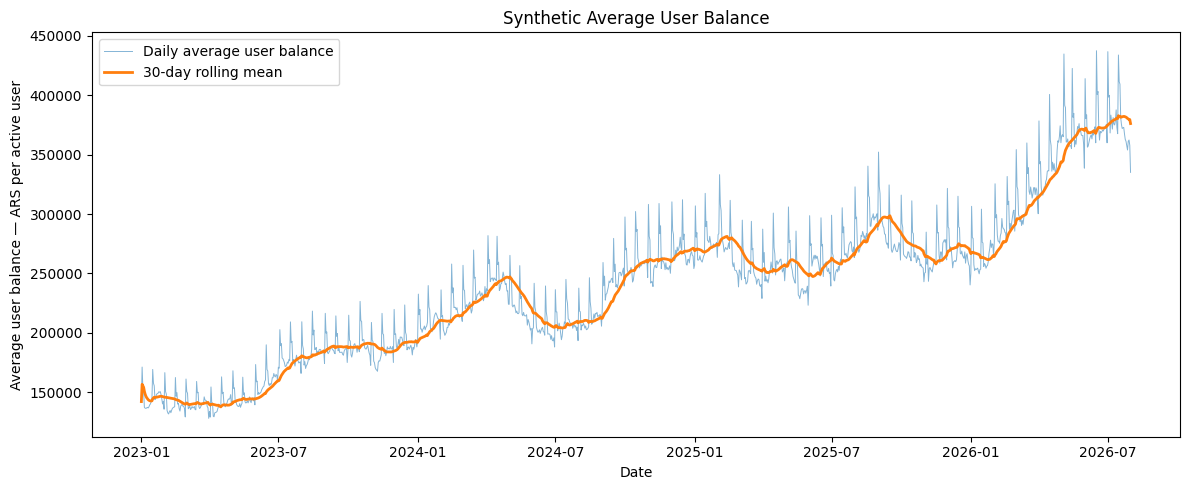

In [50]:
daily_data["average_user_balance_30d_mean"] = (
    daily_data["average_user_balance"]
    .rolling(window=30, min_periods=1)
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    daily_data["date"],
    daily_data["average_user_balance"],
    linewidth=0.7,
    alpha=0.55,
    label="Daily average user balance",
)

plt.plot(
    daily_data["date"],
    daily_data["average_user_balance_30d_mean"],
    linewidth=2,
    label="30-day rolling mean",
)

plt.title("Synthetic Average User Balance")
plt.xlabel("Date")
plt.ylabel("Average user balance — ARS per active user")
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
# Final observable daily dataset

final_columns = [
    # Date and calendar
    "date",
    "year",
    "quarter",
    "month",
    "day_of_month",
    "day_of_week",
    "day_name",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "is_holiday",
    "holiday_name",

    # Payday variables
    "is_nominal_payday",
    "is_payday",
    "is_payday_window",

    # Business events
    "is_promotion",
    "promotion_intensity",
    "system_incident",
    "system_incident_intensity",
    "is_large_merchant_settlement",
    "merchant_settlement_intensity",
    "event_count",
    "has_any_event",

    # Macroeconomic events
    "is_macro_shock",
    "macro_shock_intensity",
    "macro_shock_description",

    # Operational variables
    "active_users",
    "withdrawal_count",
    "transfer_count",
    "average_withdrawal_ticket",
    "average_transfer_ticket",
    "average_user_balance",

    # Daily cash-outflow components and target
    "withdrawal_amount",
    "outgoing_transfer_amount",
    "total_cash_outflow",

    # Macroeconomic variables
    "exchange_rate",
    "exchange_rate_change",
    "exchange_rate_volatility",
    "interest_rate",
]

missing_final_columns = [
    column
    for column in final_columns
    if column not in daily_data.columns
]

if missing_final_columns:
    raise KeyError(
        "The following required columns are missing from daily_data: "
        f"{missing_final_columns}"
    )

final_daily_data = (
    daily_data[final_columns]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

# Replace expected missing descriptions with explicit labels
final_daily_data["holiday_name"] = (
    final_daily_data["holiday_name"]
    .fillna("No holiday")
)

final_daily_data["macro_shock_description"] = (
    final_daily_data["macro_shock_description"]
    .fillna("No macro shock")
)

print(f"Final dataset shape: {final_daily_data.shape}")

final_daily_data.head()

Final dataset shape: (1308, 39)


,date,year,quarter,month,day_of_month,day_of_week,day_name,is_weekend,is_month_start,is_month_end,...,average_withdrawal_ticket,average_transfer_ticket,average_user_balance,withdrawal_amount,outgoing_transfer_amount,total_cash_outflow,exchange_rate,exchange_rate_change,exchange_rate_volatility,interest_rate
0,2023-01-01,2023,1,1,1,6,Sunday,1,1,0,...,31655.06,20202.40,142100.00,85.310,79.557,164.867,180.000000,0.000000,0.000000,0.480000
1,2023-01-02,2023,1,1,2,0,Monday,0,0,0,...,36885.20,23129.08,171167.82,147.061,278.243,425.304,179.815313,-0.001026,0.013868,0.479551
2,2023-01-03,2023,1,1,3,1,Tuesday,0,0,0,...,33149.49,21983.08,153095.44,125.537,232.581,358.118,179.834085,0.000104,0.011941,0.478971
3,2023-01-04,2023,1,1,4,2,Wednesday,0,0,0,...,34321.39,22002.51,150053.60,138.247,225.812,364.059,180.442454,0.003383,0.036523,0.477395
4,2023-01-05,2023,1,1,5,3,Thursday,0,0,0,...,31910.29,20031.34,137160.97,115.324,179.641,294.965,180.839113,0.002198,0.034397,0.475316


In [52]:
# Global quality-control audit

expected_dates = pd.date_range(
    start=PROJECT_CONFIG["start_date"],
    end=PROJECT_CONFIG["end_date"],
    freq=PROJECT_CONFIG["frequency"],
)

binary_columns = [
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "is_holiday",
    "is_nominal_payday",
    "is_payday",
    "is_payday_window",
    "is_promotion",
    "system_incident",
    "is_large_merchant_settlement",
    "has_any_event",
    "is_macro_shock",
]

positive_columns = [
    "active_users",
    "withdrawal_count",
    "transfer_count",
    "average_withdrawal_ticket",
    "average_transfer_ticket",
    "average_user_balance",
    "withdrawal_amount",
    "outgoing_transfer_amount",
    "total_cash_outflow",
    "exchange_rate",
    "interest_rate",
]

amount_columns = [
    "withdrawal_amount",
    "outgoing_transfer_amount",
    "total_cash_outflow",
]

numeric_columns = (
    final_daily_data
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

date_gaps = (
    final_daily_data["date"]
    .diff()
    .dropna()
    .dt.days
)

withdrawal_reconstructed = (
    final_daily_data["withdrawal_count"]
    * final_daily_data["average_withdrawal_ticket"]
    / 1_000_000
).round(3)

transfer_reconstructed = (
    final_daily_data["transfer_count"]
    * final_daily_data["average_transfer_ticket"]
    / 1_000_000
).round(3)

total_reconstructed = (
    final_daily_data["withdrawal_amount"]
    + final_daily_data["outgoing_transfer_amount"]
).round(3)

global_data_checks = pd.Series(
    {
        "number_of_rows": len(final_daily_data),
        "number_of_columns": len(final_daily_data.columns),

        "start_date": final_daily_data["date"].min(),
        "end_date": final_daily_data["date"].max(),

        "duplicated_dates": int(
            final_daily_data["date"]
            .duplicated()
            .sum()
        ),

        "missing_dates": len(
            expected_dates.difference(
                final_daily_data["date"]
            )
        ),

        "unexpected_dates": len(
            pd.DatetimeIndex(
                final_daily_data["date"]
            ).difference(expected_dates)
        ),

        "non_daily_date_gaps": int(
            date_gaps.ne(1).sum()
        ),

        "missing_values": int(
            final_daily_data
            .isna()
            .sum()
            .sum()
        ),

        "infinite_numeric_values": int(
            (
                ~np.isfinite(
                    final_daily_data[
                        numeric_columns
                    ].to_numpy(dtype=float)
                )
            ).sum()
        ),

        "invalid_binary_values": sum(
            int(
                (
                    ~final_daily_data[column]
                    .isin([0, 1])
                ).sum()
            )
            for column in binary_columns
        ),

        "non_positive_core_values": sum(
            int(
                final_daily_data[column]
                .le(0)
                .sum()
            )
            for column in positive_columns
        ),

        "negative_amount_values": int(
            (
                final_daily_data[amount_columns] < 0
            )
            .sum()
            .sum()
        ),

        "withdrawal_identity_mismatches": int(
            (
                final_daily_data["withdrawal_amount"]
                - withdrawal_reconstructed
            )
            .abs()
            .gt(0.001)
            .sum()
        ),

        "transfer_identity_mismatches": int(
            (
                final_daily_data[
                    "outgoing_transfer_amount"
                ]
                - transfer_reconstructed
            )
            .abs()
            .gt(0.001)
            .sum()
        ),

        "total_identity_mismatches": int(
            (
                final_daily_data["total_cash_outflow"]
                - total_reconstructed
            )
            .abs()
            .gt(0.001)
            .sum()
        ),

        "promotion_days": int(
            final_daily_data["is_promotion"].sum()
        ),

        "system_incident_days": int(
            final_daily_data["system_incident"].sum()
        ),

        "merchant_settlement_days": int(
            final_daily_data[
                "is_large_merchant_settlement"
            ].sum()
        ),

        "macro_shock_days": int(
            final_daily_data["is_macro_shock"].sum()
        ),
    },
    name="value",
).rename_axis("check").reset_index()

global_data_checks

,check,value
0,number_of_rows,1308
1,number_of_columns,39
2,start_date,2023-01-01 00:00:00
3,end_date,2026-07-31 00:00:00
4,duplicated_dates,0
5,missing_dates,0
6,unexpected_dates,0
7,non_daily_date_gaps,0
8,missing_values,0
9,infinite_numeric_values,0


In [53]:
# Final target-variable summary

target = final_daily_data["total_cash_outflow"]

withdrawal_share = (
    final_daily_data["withdrawal_amount"]
    / final_daily_data["total_cash_outflow"]
)

transfer_share = (
    final_daily_data["outgoing_transfer_amount"]
    / final_daily_data["total_cash_outflow"]
)

target_summary = pd.Series(
    {
        "unit": PROJECT_CONFIG["monetary_unit"],

        "minimum": round(target.min(), 2),
        "p01": round(target.quantile(0.01), 2),
        "p05": round(target.quantile(0.05), 2),
        "median": round(target.median(), 2),
        "mean": round(target.mean(), 2),
        "p95": round(target.quantile(0.95), 2),
        "p99": round(target.quantile(0.99), 2),
        "maximum": round(target.max(), 2),

        "standard_deviation": round(
            target.std(),
            2,
        ),

        "coefficient_of_variation": round(
            target.std() / target.mean(),
            3,
        ),

        "skewness": round(
            target.skew(),
            3,
        ),

        "first_30_days_mean": round(
            target.head(30).mean(),
            2,
        ),

        "last_30_days_mean": round(
            target.tail(30).mean(),
            2,
        ),

        "last_to_first_30d_ratio": round(
            target.tail(30).mean()
            / target.head(30).mean(),
            3,
        ),

        "mean_withdrawal_share": round(
            withdrawal_share.mean(),
            3,
        ),

        "mean_transfer_share": round(
            transfer_share.mean(),
            3,
        ),
    },
    name="value",
).rename_axis("statistic").reset_index()

target_summary

,statistic,value
0,unit,ARS million
1,minimum,149.45
2,p01,193.04
3,p05,264.75
4,median,605.25
5,mean,660.63
6,p95,1203.54
7,p99,1569.77
8,maximum,1896.16
9,standard_deviation,304.01


In [54]:
# Final dataset assertions

assert len(final_daily_data) == len(expected_dates), (
    "The final dataset has an unexpected number of rows."
)

assert final_daily_data["date"].duplicated().sum() == 0, (
    "Duplicated dates were detected."
)

assert len(
    expected_dates.difference(
        final_daily_data["date"]
    )
) == 0, (
    "Missing dates were detected."
)

assert date_gaps.eq(1).all(), (
    "The dataset does not have a continuous daily frequency."
)

assert final_daily_data.isna().sum().sum() == 0, (
    "Missing values were detected."
)

assert np.isfinite(
    final_daily_data[
        numeric_columns
    ].to_numpy(dtype=float)
).all(), (
    "Infinite numeric values were detected."
)

for column in binary_columns:
    assert final_daily_data[column].isin([0, 1]).all(), (
        f"Invalid binary values were detected in {column}."
    )

for column in positive_columns:
    assert final_daily_data[column].gt(0).all(), (
        f"Non-positive values were detected in {column}."
    )

assert (
    final_daily_data["withdrawal_amount"]
    - withdrawal_reconstructed
).abs().max() <= 0.001, (
    "The withdrawal identity is not satisfied."
)

assert (
    final_daily_data["outgoing_transfer_amount"]
    - transfer_reconstructed
).abs().max() <= 0.001, (
    "The transfer identity is not satisfied."
)

assert (
    final_daily_data["total_cash_outflow"]
    - total_reconstructed
).abs().max() <= 0.001, (
    "The total cash-outflow identity is not satisfied."
)

print("Final daily dataset validation passed successfully.")

Final daily dataset validation passed successfully.


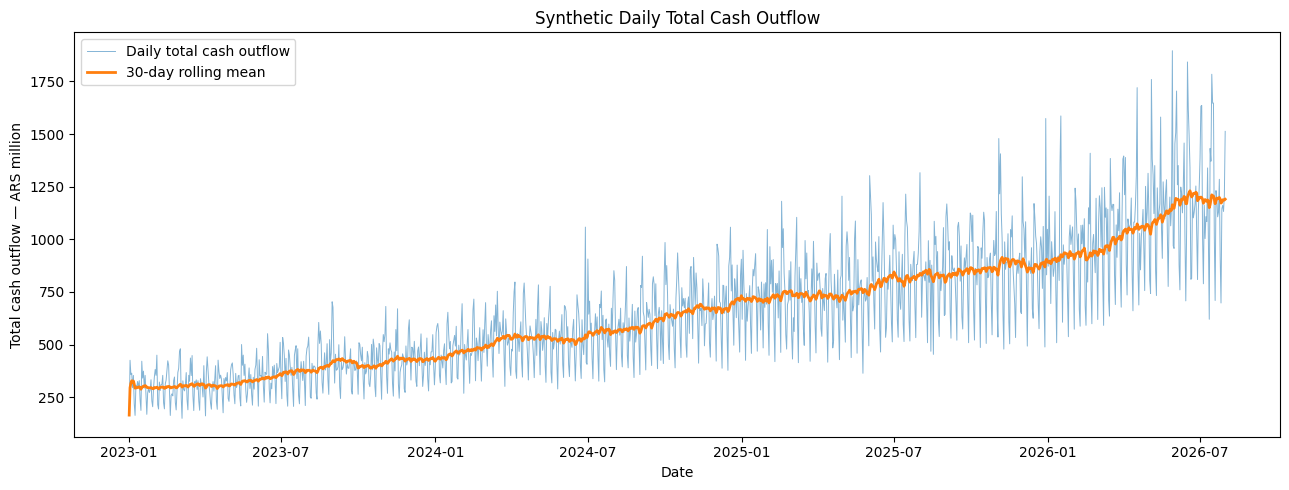

In [55]:
# Temporal visualization of the forecasting target

target_30d_mean = (
    final_daily_data["total_cash_outflow"]
    .rolling(window=30, min_periods=1)
    .mean()
)

plt.figure(figsize=(13, 5))

plt.plot(
    final_daily_data["date"],
    final_daily_data["total_cash_outflow"],
    linewidth=0.7,
    alpha=0.55,
    label="Daily total cash outflow",
)

plt.plot(
    final_daily_data["date"],
    target_30d_mean,
    linewidth=2,
    label="30-day rolling mean",
)

plt.title("Synthetic Daily Total Cash Outflow")
plt.xlabel("Date")
plt.ylabel("Total cash outflow — ARS million")
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
from pathlib import Path
import json

# ---------------------------------------------------------
# Resolve project paths
# ---------------------------------------------------------

CURRENT_DIR = Path.cwd()

PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
FIGURES_DIR = PROJECT_ROOT / "figures"

DATA_RAW_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------
# Final validation before saving
# ---------------------------------------------------------

expected_dates = pd.date_range(
    start=PROJECT_CONFIG["start_date"],
    end=PROJECT_CONFIG["end_date"],
    freq=PROJECT_CONFIG["frequency"],
)

binary_columns = [
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "is_holiday",
    "is_nominal_payday",
    "is_payday",
    "is_payday_window",
    "is_promotion",
    "system_incident",
    "is_large_merchant_settlement",
    "has_any_event",
    "is_macro_shock",
]

positive_columns = [
    "active_users",
    "withdrawal_count",
    "transfer_count",
    "average_withdrawal_ticket",
    "average_transfer_ticket",
    "average_user_balance",
    "withdrawal_amount",
    "outgoing_transfer_amount",
    "total_cash_outflow",
    "exchange_rate",
    "interest_rate",
]

withdrawal_reconstructed = (
    final_daily_data["withdrawal_count"]
    * final_daily_data["average_withdrawal_ticket"]
    / 1_000_000
).round(3)

transfer_reconstructed = (
    final_daily_data["transfer_count"]
    * final_daily_data["average_transfer_ticket"]
    / 1_000_000
).round(3)

total_reconstructed = (
    final_daily_data["withdrawal_amount"]
    + final_daily_data["outgoing_transfer_amount"]
).round(3)

assert len(final_daily_data) == len(expected_dates)
assert final_daily_data["date"].duplicated().sum() == 0
assert len(expected_dates.difference(final_daily_data["date"])) == 0
assert final_daily_data["date"].diff().dropna().dt.days.eq(1).all()
assert final_daily_data.isna().sum().sum() == 0

numeric_data = final_daily_data.select_dtypes(
    include=[np.number]
)

assert np.isfinite(
    numeric_data.to_numpy(dtype=float)
).all()

for column in binary_columns:
    assert final_daily_data[column].isin([0, 1]).all(), (
        f"Invalid binary values detected in {column}."
    )

for column in positive_columns:
    assert final_daily_data[column].gt(0).all(), (
        f"Non-positive values detected in {column}."
    )

assert (
    final_daily_data["withdrawal_amount"]
    - withdrawal_reconstructed
).abs().max() <= 0.001

assert (
    final_daily_data["outgoing_transfer_amount"]
    - transfer_reconstructed
).abs().max() <= 0.001

assert (
    final_daily_data["total_cash_outflow"]
    - total_reconstructed
).abs().max() <= 0.001


# ---------------------------------------------------------
# Output paths
# ---------------------------------------------------------

daily_data_path = (
    DATA_RAW_DIR
    / "synthetic_fintech_daily.csv"
)

event_calendar_path = (
    DATA_RAW_DIR
    / "synthetic_event_calendar.csv"
)

event_specs_path = (
    DATA_RAW_DIR
    / "synthetic_event_specifications.csv"
)

macro_shocks_path = (
    DATA_RAW_DIR
    / "synthetic_macro_shocks.csv"
)

generation_config_path = (
    DATA_RAW_DIR
    / "synthetic_generation_config.json"
)


# ---------------------------------------------------------
# Save datasets
# ---------------------------------------------------------

final_daily_data.to_csv(
    daily_data_path,
    index=False,
    date_format="%Y-%m-%d",
)

events.to_csv(
    event_calendar_path,
    index=False,
    date_format="%Y-%m-%d",
)

event_specs.to_csv(
    event_specs_path,
    index=False,
    date_format="%Y-%m-%d",
)

macro_shocks.to_csv(
    macro_shocks_path,
    index=False,
    date_format="%Y-%m-%d",
)


# ---------------------------------------------------------
# Save generator configuration
# ---------------------------------------------------------

generation_config = {
    "project": PROJECT_CONFIG,
    "active_users": USER_GENERATION_CONFIG,
    "transaction_counts": TRANSACTION_COUNT_CONFIG,
    "macroeconomic_environment": MACRO_CONFIG,
    "transaction_tickets": TICKET_CONFIG,
    "average_user_balance": BALANCE_CONFIG,
    "dataset_shape": {
        "rows": int(final_daily_data.shape[0]),
        "columns": int(final_daily_data.shape[1]),
    },
    "dataset_columns": final_daily_data.columns.tolist(),
}


def json_converter(value):
    """Convert NumPy and pandas objects into JSON-compatible values."""
    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, pd.Timestamp):
        return value.strftime("%Y-%m-%d")

    raise TypeError(
        f"Object of type {type(value).__name__} is not JSON serializable."
    )


with generation_config_path.open(
    mode="w",
    encoding="utf-8",
) as file:
    json.dump(
        generation_config,
        file,
        indent=2,
        ensure_ascii=False,
        default=json_converter,
    )


# ---------------------------------------------------------
# Confirm saved files
# ---------------------------------------------------------

saved_files = pd.DataFrame(
    [
        {
            "file": path.name,
            "exists": path.exists(),
            "size_kb": round(
                path.stat().st_size / 1024,
                2,
            ),
        }
        for path in [
            daily_data_path,
            event_calendar_path,
            event_specs_path,
            macro_shocks_path,
            generation_config_path,
        ]
    ]
)

assert saved_files["exists"].all(), (
    "At least one output file was not saved."
)

print("Final daily dataset validation passed successfully.")
print(f"Files saved in: {DATA_RAW_DIR.resolve()}")

saved_files

Final daily dataset validation passed successfully.
Files saved in: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\data\raw


,file,exists,size_kb
0,synthetic_fintech_daily.csv,True,320.49
1,synthetic_event_calendar.csv,True,3.09
2,synthetic_event_specifications.csv,True,1.67
3,synthetic_macro_shocks.csv,True,0.25
4,synthetic_generation_config.json,True,3.39


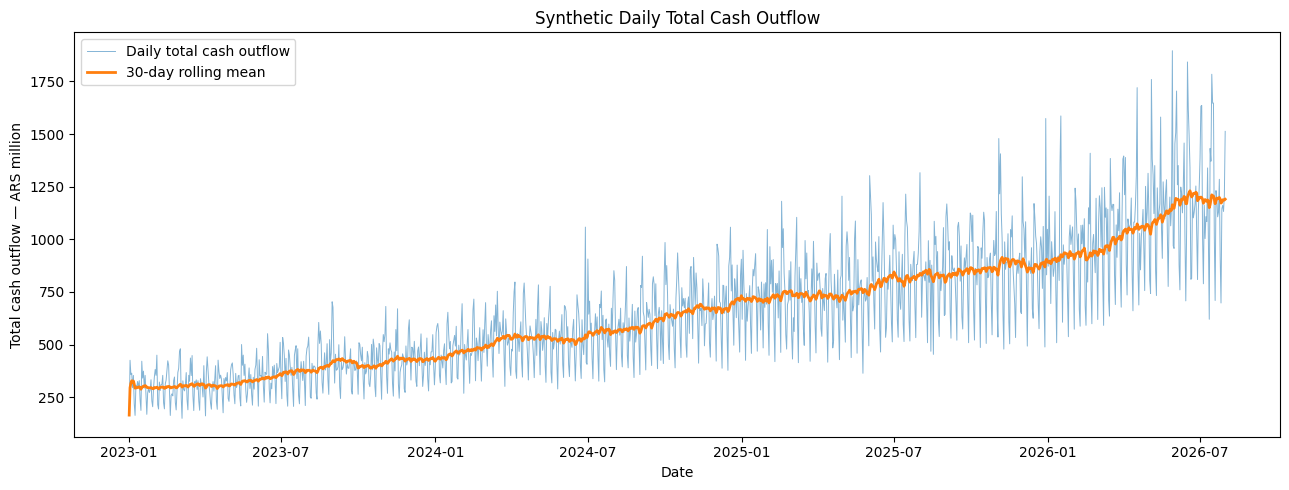

Figure saved at: C:\Users\Peter\ai-imaging-portfolio\projects\06_fintech-liquidity-forecasting\figures\01_synthetic_total_cash_outflow.png


In [57]:
target_30d_mean = (
    final_daily_data["total_cash_outflow"]
    .rolling(window=30, min_periods=1)
    .mean()
)

target_figure_path = (
    FIGURES_DIR
    / "01_synthetic_total_cash_outflow.png"
)

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    final_daily_data["date"],
    final_daily_data["total_cash_outflow"],
    linewidth=0.7,
    alpha=0.55,
    label="Daily total cash outflow",
)

ax.plot(
    final_daily_data["date"],
    target_30d_mean,
    linewidth=2,
    label="30-day rolling mean",
)

ax.set_title("Synthetic Daily Total Cash Outflow")
ax.set_xlabel("Date")
ax.set_ylabel("Total cash outflow — ARS million")
ax.legend()

fig.tight_layout()

fig.savefig(
    target_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Figure saved at: {target_figure_path.resolve()}")

## Conclusion

This notebook defined the business problem and generated a realistic,
reproducible synthetic dataset representing daily cash outflows from a
Fintech operation.

The final dataset contains **1,308 consecutive daily observations** from
January 1, 2023, to July 31, 2026, and **39 observable variables** describing:

- Calendar and payday effects.
- Active-user growth.
- Withdrawal and outgoing-transfer activity.
- Average transaction tickets.
- Average user balances.
- Holidays, promotions, system incidents, and exceptional merchant settlements.
- A synthetic exchange-rate and interest-rate environment.
- Documented macroeconomic shocks.
- Daily cash-outflow components and the final forecasting target.

The target variable, `total_cash_outflow`, is expressed in ARS millions and
satisfies the following accounting identity:

$$
\text{total\_cash\_outflow}
=
\text{withdrawal\_amount}
+
\text{outgoing\_transfer\_amount}
$$

The generated target has:

- A mean of **660.63 ARS million**.
- A median of **605.25 ARS million**.
- A 95th percentile of **1,203.54 ARS million**.
- A maximum of **1,896.16 ARS million**.
- Moderate positive skewness of **0.794**.
- An average composition of **41.1% withdrawals** and **58.9% outgoing transfers**.

All calendar, range, missing-value, binary-variable, event-count, and
accounting-identity checks passed successfully.

The dataset therefore passes **Gate 1 — Data Generation** and is ready for
time-series exploratory analysis in:

`02_time_series_eda.ipynb`